In [14]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LinearRegression
import csv
df = pd.read_csv('c:/Gen-AI/Py-training/house_price_prediction_dataset.csv')
df.head()
df.info()
print (df.isna().sum())
print (df.describe())
df.drop(['Id','MSSubClass','Alley','PoolQC','Fence','MiscFeature'], axis=1,inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Category Fields

In [5]:
category_df = df.select_dtypes(exclude=['number'])
print (category_df)

     MSZoning Street LotShape LandContour Utilities LotConfig LandSlope  \
0          RL   Pave      Reg         Lvl    AllPub    Inside       Gtl   
1          RL   Pave      Reg         Lvl    AllPub       FR2       Gtl   
2          RL   Pave      IR1         Lvl    AllPub    Inside       Gtl   
3          RL   Pave      IR1         Lvl    AllPub    Corner       Gtl   
4          RL   Pave      IR1         Lvl    AllPub       FR2       Gtl   
...       ...    ...      ...         ...       ...       ...       ...   
1455       RL   Pave      Reg         Lvl    AllPub    Inside       Gtl   
1456       RL   Pave      Reg         Lvl    AllPub    Inside       Gtl   
1457       RL   Pave      Reg         Lvl    AllPub    Inside       Gtl   
1458       RL   Pave      Reg         Lvl    AllPub    Inside       Gtl   
1459       RL   Pave      Reg         Lvl    AllPub    Inside       Gtl   

     Neighborhood Condition1 Condition2  ... KitchenQual Functional  \
0         CollgCr       Norm

### Numerical Fields

In [6]:
numerical_df = df.select_dtypes(include=['number'])
numerical_df.drop(['SalePrice'], axis=1,inplace=True)
print (numerical_df)

      LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  YearRemodAdd  \
0            65.0     8450            7            5       2003          2003   
1            80.0     9600            6            8       1976          1976   
2            68.0    11250            7            5       2001          2002   
3            60.0     9550            7            5       1915          1970   
4            84.0    14260            8            5       2000          2000   
...           ...      ...          ...          ...        ...           ...   
1455         62.0     7917            6            5       1999          2000   
1456         85.0    13175            6            6       1978          1988   
1457         66.0     9042            7            9       1941          2006   
1458         68.0     9717            5            6       1950          1996   
1459         75.0     9937            5            6       1965          1965   

      MasVnrArea  BsmtFinSF

In [7]:
target = ['SalePrice'] 
y = df[target].values
X = df.drop('SalePrice', axis=1) 
features= X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7) # 70% training and 30% test
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
print (X_train.shape)

num_column_list = X_test.select_dtypes(include='number').columns.tolist() 
cat_column_list =  X_test.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_transformer = SimpleImputer(strategy='median')
categorical_transformer = SimpleImputer(strategy='most_frequent')


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_column_list),
        ('cat', categorical_transformer, cat_column_list)
    ])

X_train_transformmissing = preprocessor.fit_transform(X_train)
X_test_transformmissing =  preprocessor.fit_transform(X_test)
X_train_transformmissing = pd.DataFrame(X_train_transformmissing)
X_test_transformmissing = pd.DataFrame(X_test_transformmissing)
print("1")
print(X_train_transformmissing.shape)

cat_cols = X_train_transformmissing.select_dtypes(include=['object', 'category']).columns.tolist()

ct = ColumnTransformer(transformers=[
    ('ord', OrdinalEncoder(), cat_cols)
], remainder='passthrough')



X_train_transformed = np.round(ct.fit_transform(X_train_transformmissing),2)
X_test_transformed = np.round(ct.fit_transform(X_test_transformmissing),2)

print (X_train_transformed.shape)
print (X_test_transformed.shape)
print (X_test_transformed.shape[1])
for i in range(X_train_transformed.shape[1]):
    # minimum and maximum of the feature in the training set
    minimum = X_train_transformed[:,i].min()
    maximum = X_train_transformed[:,i].max()

    if maximum != minimum :
            # Use the minimum and maximum of the feature in the training set to normalize both the training and test set
        X_train_transformed[:,i] = (X_train_transformed[:,i] - minimum)/(maximum - minimum)
        if i < X_test_transformed.shape[1]: 
            X_test_transformed[:,i] = (X_test_transformed[:,i] - minimum)/(maximum - minimum)
    '''else:
        X_train_transformed[:,i] = 0
        X_test_transformed[:,i] = 0 
print (X_train_transformed[0:5])
print (X_test_transformed[0:5])'''
print("2")
print (X_train_transformed.shape)
k = len(features)
print (k)
theta = np.random.rand(k+1)
x_0_train = np.ones(shape=X_train_transformed.shape[0])
print(x_0_train)
print (x_0_train.shape)
X_train_transformed = np.hstack((x_0_train.reshape(-1,1), X_train_transformed))
x_0_test = np.ones(shape=X_test.shape[0])
X_test_transformed = np.hstack((x_0_test.reshape(-1,1), X_test_transformed))

print("3")
print (X_train_transformed.shape)
X_train_transformed[0:5]
X_test_transformed.shape
X_test[0:5]
theta.reshape(1,-1).shape

X_train_transformed.shape
print(theta.reshape(1,-1).shape)


def predict(params, X):
    return (X @ params.reshape(-1,1))
y_pred = predict(theta, X_train_transformed)
y_pred[0:5]
y_train[0:5]
y_pred.shape, y_train.shape, X_train_transformed.shape, theta.shape

def cost_function(y_pred, y_actual):
    errors = y_pred - y_actual
    return np.square(errors).sum()/(2*y_pred.shape[0])


(1021, 74)
1
(1021, 74)
(1021, 74)
(439, 74)
74
2
(1021, 74)
74
[1. 1. 1. ... 1. 1. 1.]
(1021,)
3
(1021, 75)
(1, 75)


In [8]:
def gradient_descent_linear_reg(X_values, y_values, theta_init, iterations = 1000, alpha = 0.01, alpha_scaling = False, tolerance = 0.0001):
    """
    inputs:
    -------
    X_values : training samples of features
    y_values : values of target varaible
    theta_init : initial values of model parameters
    tolerance : the minimum change in theta required
    iterations : total number of iterations
    alpha : learning rate
    alpha_scaling : moderate the value of learning rate
    
    output:
    -------
    theta : optimized model parameter
    cost_values : list of cost values
    """
    cost_values = []                      # starting with an empty list, will append the value of the cost function in each iteration.
    theta = theta_init                    # initializing the theta 
    it = 0                                # start with the iteration count = 0
    m = X_values.shape[0]                 # m = number of data / samples
    alpha_max = alpha                     # maximum value of learning rate
    alpha_min = alpha/100                 # minimum value of learning rate (will be used, if we use alpha scaling)
    
    #-------- Gradient descent algorithm -----------#

    while(it < iterations):                                 # Using max iteration stopping criteria inside a while loop
        y_pred = predict(theta, X_values)                   # Predicted value of the target variable
        cost = cost_function(y_pred, y_values)              # Calculate the cost function given predicted and actual values
        cost_values.append(cost)
        
        # alpha scaling
        if alpha_scaling:
            alpha = alpha_max - ((alpha_max - alpha_min)/(iterations))*it
        
        # gradient descent update rule
        del_theta = ((-1*alpha / m) * (X_values.T @ (y_pred - y_values)).flatten())
        theta = theta + del_theta

        it += 1                     # incrementing iteration count by 1

        # stopping criteria
        del_theta_mag = np.linalg.norm(del_theta)
        if del_theta_mag < tolerance:
            break
        
    return theta, cost_values, it
model_params, costs, max_it = gradient_descent_linear_reg(X_train_transformed, y_train, theta, iterations=10000, alpha=0.01, tolerance=1e-4, alpha_scaling=False)
model_params


array([ 12421.11215324,    867.89179419,  17105.23194915,  64385.65578312,
        34959.87920682,   9145.31908847,   8664.00083867,  15110.26632351,
        27785.11523382,   7108.56661848,    433.33872692,  28842.63555774,
        16483.26143983,  29129.18676814,  -5484.26425907,  37457.07987095,
         8164.20200247,  -1843.7036089 ,  17567.61962183,  12069.96343348,
       -11669.09915696, -16349.57661781,  12543.69033656,  18965.83941624,
         -355.0005826 ,  13965.1230679 ,  13932.03105714,   8079.27157603,
          250.40908365,    358.72781417,   1347.09657044,   1733.10597839,
        -8826.33169597,  -6108.58122031,  -1348.71022699,  -3133.39675948,
         1531.71048011,  15806.61915486,  -1551.94051511,   7026.19689268,
        -1301.06467833,   1715.89285305,  11429.45421346,   3802.66025551,
        -1959.99608557,  -5641.73149006, -11246.17999149,  -8827.76779235,
         5842.28888619,  28359.03811704, -10562.40459506,   3171.99407134,
         5141.95450065, -

In [9]:

max_it

10000

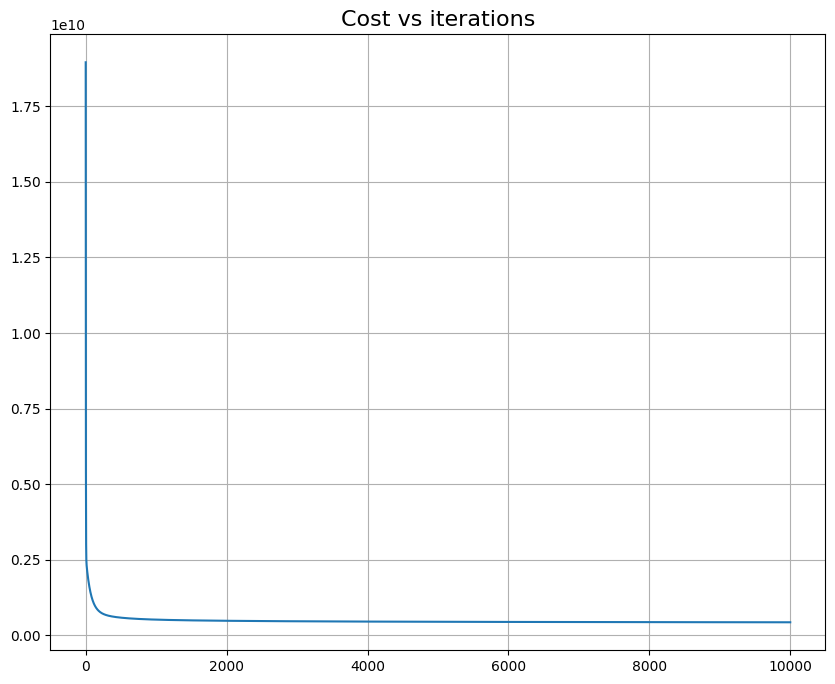

In [7]:

plt.figure(figsize=(10,8))
plt.plot(costs)
plt.grid()
plt.title("Cost vs iterations", fontsize=16)
plt.show()

In [8]:
model_output = predict(model_params, X_train_transformed)
pd.DataFrame(np.hstack((model_output, y_train, model_output-y_train)), columns=['Predicted values', 'Actual values', 'Errors'])

,Predicted values,Actual values,Errors
0,236282.097655,220000.0,16282.097655
1,132248.359085,124000.0,8248.359085
2,405536.037105,582933.0,-177396.962895
3,108775.731474,109500.0,-724.268526
4,95744.573881,102776.0,-7031.426119
...,...,...,...
1016,191331.363477,190000.0,1331.363477
1017,290675.512617,328000.0,-37324.487383
1018,140136.241246,160000.0,-19863.758754
1019,409078.756058,538000.0,-128921.243942


In [9]:
cost_function(model_output, y_train).item()

427964568.5127052

In [10]:
model = LinearRegression(tol=1e-4)

In [11]:
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",0.0001
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
model.fit(X_train_transformed[:,1:], y_train)   # training the model  (x_0 column is not required)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",0.0001
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
y_pred_train = model.predict(X_train_transformed[:,1:])

In [14]:
pd.DataFrame(np.hstack((y_pred_train, y_train, y_pred_train-y_train)), columns=['Predicted values', 'Actual values', 'Errors'])

,Predicted values,Actual values,Errors
0,239005.008445,220000.0,19005.008445
1,137488.725157,124000.0,13488.725157
2,414068.561203,582933.0,-168864.438797
3,116869.454277,109500.0,7369.454277
4,107664.495628,102776.0,4888.495628
...,...,...,...
1016,190289.432082,190000.0,289.432082
1017,293320.592394,328000.0,-34679.407606
1018,124913.799140,160000.0,-35086.200860
1019,427868.471295,538000.0,-110131.528705


In [15]:
cost_function(y_pred_train, y_train).item()

410407718.625432

In [16]:
y_pred_test = model.predict(X_test_transformed[:,1:])

In [17]:
pd.DataFrame(np.hstack((y_pred_test, y_test, y_pred_test-y_test)), columns=['Predicted values', 'Actual values', 'Errors'])

,Predicted values,Actual values,Errors
0,156392.467487,155000.0,1392.467487
1,200864.605218,192500.0,8364.605218
2,151769.212519,146800.0,4969.212519
3,158344.648555,177000.0,-18655.351445
4,161295.965618,140000.0,21295.965618
...,...,...,...
434,237491.377944,258000.0,-20508.622056
435,151394.284542,176000.0,-24605.715458
436,236960.860558,220000.0,16960.860558
437,163478.527354,151000.0,12478.527354


In [20]:

cost_function(y_pred_test, y_test).item()

924034963.669122

In [21]:
model.intercept_

array([33471.94084806])

In [22]:
model.coef_ 

array([[ 2.22982946e+03,  2.07736926e+04,  9.74841048e+04,
         4.29889807e+04,  1.54099471e+04,  4.62954078e+02,
         8.29503628e+03,  1.13105869e+04,  5.59408727e+03,
        -1.21174548e+04,  3.98565080e+04,  2.26153375e+04,
         3.66037118e+04,  2.76632949e+03,  1.49259588e+04,
         4.35476213e+03, -9.35747833e+03,  1.65735287e+04,
         4.85441811e+03, -2.98428371e+04, -8.10823334e+04,
         5.72659889e+04,  1.10190722e+04, -7.36806812e+02,
         1.92868361e+04,  8.36822249e+03,  5.29856745e+03,
         3.55031852e+01,  4.91762645e+03,  8.06943197e+03,
         1.87422042e+04, -4.12546305e+03, -4.59132855e+03,
         2.43265004e+03, -3.47265826e+03, -3.06331708e+03,
         2.37867002e+04,  1.56907246e+03,  9.80133370e+03,
         0.00000000e+00,  2.79899411e+03,  2.78372772e+04,
         9.40431045e+03, -3.26860443e+03, -6.75524843e+04,
        -7.78526178e+03, -4.84021942e+03,  4.46806991e+03,
         1.51064251e+04, -2.24058536e+04,  1.81513279e+0

In [23]:
model_params

array([ 1.11153492e+04,  2.48020877e+03,  1.80351193e+04,  6.57790500e+04,
        3.48069897e+04,  1.04822807e+04,  4.49800218e+03,  9.06190445e+03,
        2.15166941e+04,  1.15354123e+04,  2.56811010e+02,  2.75533494e+04,
        2.11742135e+04,  3.34289411e+04,  4.44295679e+03,  2.90102315e+04,
        3.06572660e+03, -6.36992639e+03,  1.53563197e+04,  5.63924226e+03,
       -8.39365398e+03, -2.20430395e+04,  2.04229732e+04,  1.77238143e+04,
       -1.08502472e+02,  1.94673467e+04,  1.13822107e+04,  6.37417711e+03,
        1.42910744e+03,  5.86130352e+03,  3.08325879e+03,  1.90035362e+04,
       -1.72581176e+02, -3.97285999e+02,  1.10952273e+03, -3.67610767e+03,
        1.35689816e+02,  1.66694804e+04,  1.25670700e+03,  7.57696814e+03,
        2.04809102e-01,  2.26567370e+03,  1.96639268e+04,  8.43991620e+03,
        7.84104923e+02, -2.31869032e+03, -1.06437619e+04, -3.70977649e+03,
        6.50001244e+03,  1.27437403e+04, -1.29466774e+04,  9.86063364e+03,
        1.57146871e+04, -

### Random Forest Model
Random Forest Classifier is typically not the right tool for a continuous numeric target variable. While it may sometimes run without error if the numbers are treated as distinct categories, it will generally fail to provide accurate results for continuous data

In [10]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=200, min_samples_split=10)
clf.fit(X_train_transformed, y_train)
clf

c:\Gen-AI\Py-training\myenv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Gen-AI\Py-training\myenv\Lib\site-packages\sklearn\ensemble\_forest.py:830: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Gen-AI\Py-training\myenv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Gen-AI\Py-training\myenv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

#Predict the response for test dataset
y_pred = clf.predict(X_test_transformed)

# Evaluating the model on train dataset
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.0137


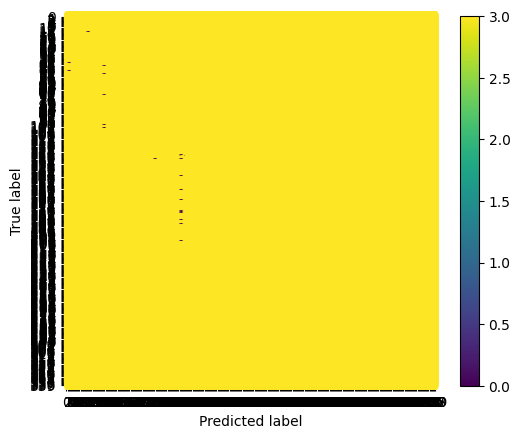

In [8]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot();

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       34900       0.00      0.00      0.00         1
       52000       0.00      0.00      0.00         0
       55993       0.00      0.00      0.00         1
       58500       0.00      0.00      0.00         1
       60000       0.00      0.00      0.00         0
       61000       0.00      0.00      0.00         0
       67000       0.00      0.00      0.00         1
       68500       0.00      0.00      0.00         1
       72500       0.00      0.00      0.00         0
       75000       0.00      0.00      0.00         1
       79000       0.00      0.00      0.00         2
       79900       0.00      0.00      0.00         1
       80000       0.00      0.00      0.00         0
       80500       0.00      0.00      0.00         1
       82000       0.00      0.00      0.00         1
       82500       0.00      0.00      0.00         2
       83000       0.00      0.00      0.00         1
       84000       0.00    

c:\Gen-AI\Py-training\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Gen-AI\Py-training\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Gen-AI\Py-training\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Gen-AI\Py-training\myenv

In [14]:
clf = RandomForestClassifier(n_estimators=200, min_samples_split=10, oob_score=True)

clf.fit(X_train_transformed, y_train)

clf

c:\Gen-AI\Py-training\myenv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Gen-AI\Py-training\myenv\Lib\site-packages\sklearn\ensemble\_forest.py:830: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Gen-AI\Py-training\myenv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Gen-AI\Py-training\myenv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [15]:
clf.oob_score_

0.013712047012732615

In [16]:
oob_error = 1 - clf.oob_score_

oob_error

0.9862879529872673

### Decision Tree
Decision Tree Classifier is specifically designed for categorical target variables (classes), it is technically correct that it will fail or produce incorrect results if you attempt to use it directly on a truly continuous target variable without modification

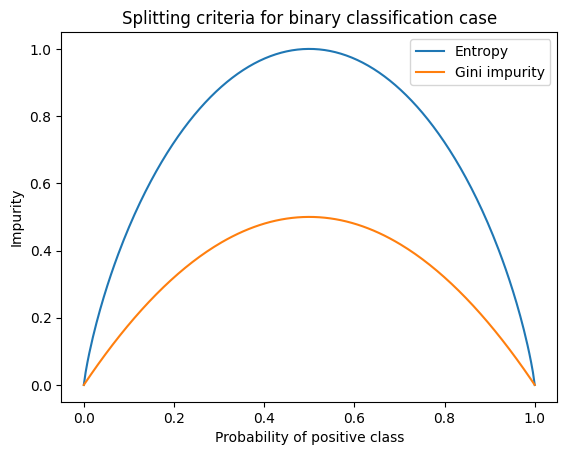

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
def gini(probas):
    return np.array([1- (p ** 2 + (1-p) ** 2) for p in probas])
def entropy(probas):
    return np.array([-1 * (p * np.log2(p) + (1-p) * np.log2(1-p)) for p in probas])
eps = 1e-10  # remove log0 to occur.
probas = np.linspace(eps, 1-eps, 250)
plt.plot(probas, entropy(probas), label="Entropy")
plt.plot(probas, gini(probas), label="Gini impurity")
plt.title("Splitting criteria for binary classification case")
plt.xlabel("Probability of positive class")
plt.ylabel("Impurity")
plt.legend()
plt.show()

In [35]:
# Train the classifier
clf = DecisionTreeClassifier()
clf.fit(X_train_transformed, y_train)

clf

c:\Gen-AI\Py-training\myenv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

### Decision Tree Classifer cannot be used as is not designed for predicting continuous house prices directly and consider each unique housing price as a classifier.

### Decision Tree Regression

[ 1.68076571e-01 -2.24620176e-04 -8.18002185e-02  1.23018674e-02
 -5.50533968e-02 -6.16730110e-02  4.33184067e-02 -1.60372948e-01
 -1.44392892e-01  1.92908804e-03 -2.23085389e-03  3.43554577e-02
  1.87522539e-01  1.04514036e-02  5.98172150e-02 -9.75532936e-02
  7.67937664e-02 -5.26390865e-02  7.14208326e-03 -1.08848625e-02
  1.03297423e-01 -1.30997655e-01 -2.28323863e-01 -2.13432697e-02
  4.68531257e-02  1.52269376e-02  1.23220424e-01  4.37372674e-02
 -5.63848332e-02 -2.32542015e-01 -2.37312234e-02  1.02795900e-01
 -3.92047783e-02  2.83202637e-03  4.21360254e-02 -1.01529237e-01
  6.23235897e-02  1.63712179e-01 -1.72813352e-02 -1.12906442e-01
 -6.66010270e-03 -2.22438411e-01  3.36903264e-02  4.52274378e-02
  1.67563629e-01 -1.93994793e-02  4.08485338e-02 -8.61288102e-02
 -3.56427121e-02 -1.52518544e-01 -1.94789621e-02 -3.05309154e-02
  2.99199766e-02 -6.23596880e-02  8.33453510e-03 -3.33380056e-02
 -3.31499388e-02  8.03623260e-03  4.05229423e-03  7.61174039e-02
 -1.20643034e-02 -3.49885

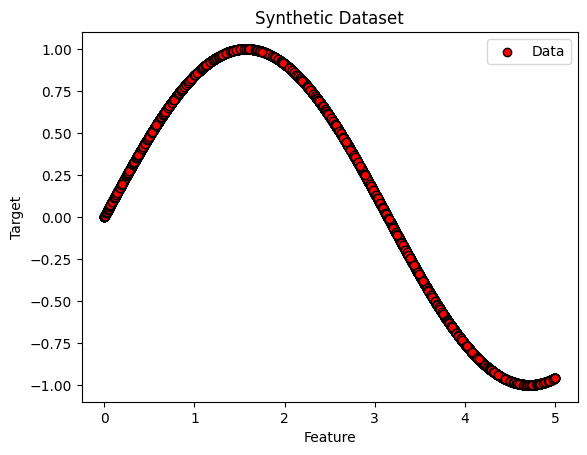

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression
np.random.seed(42)
X = np.sort(5 * np.random.rand(200, 75), axis=0)
y = np.sin(X).ravel()  
plt.scatter(X, y, color='red', label='Data', edgecolor='k')
plt.title("Synthetic Dataset")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()


In [101]:
regressor = DecisionTreeRegressor(max_depth=4,random_state=42)

regressor.fit(X_train_transformed, y_train)

regressor

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [102]:
# predicting on test dataset
y_pred = regressor.predict(X_test_transformed)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 5723285521.5834


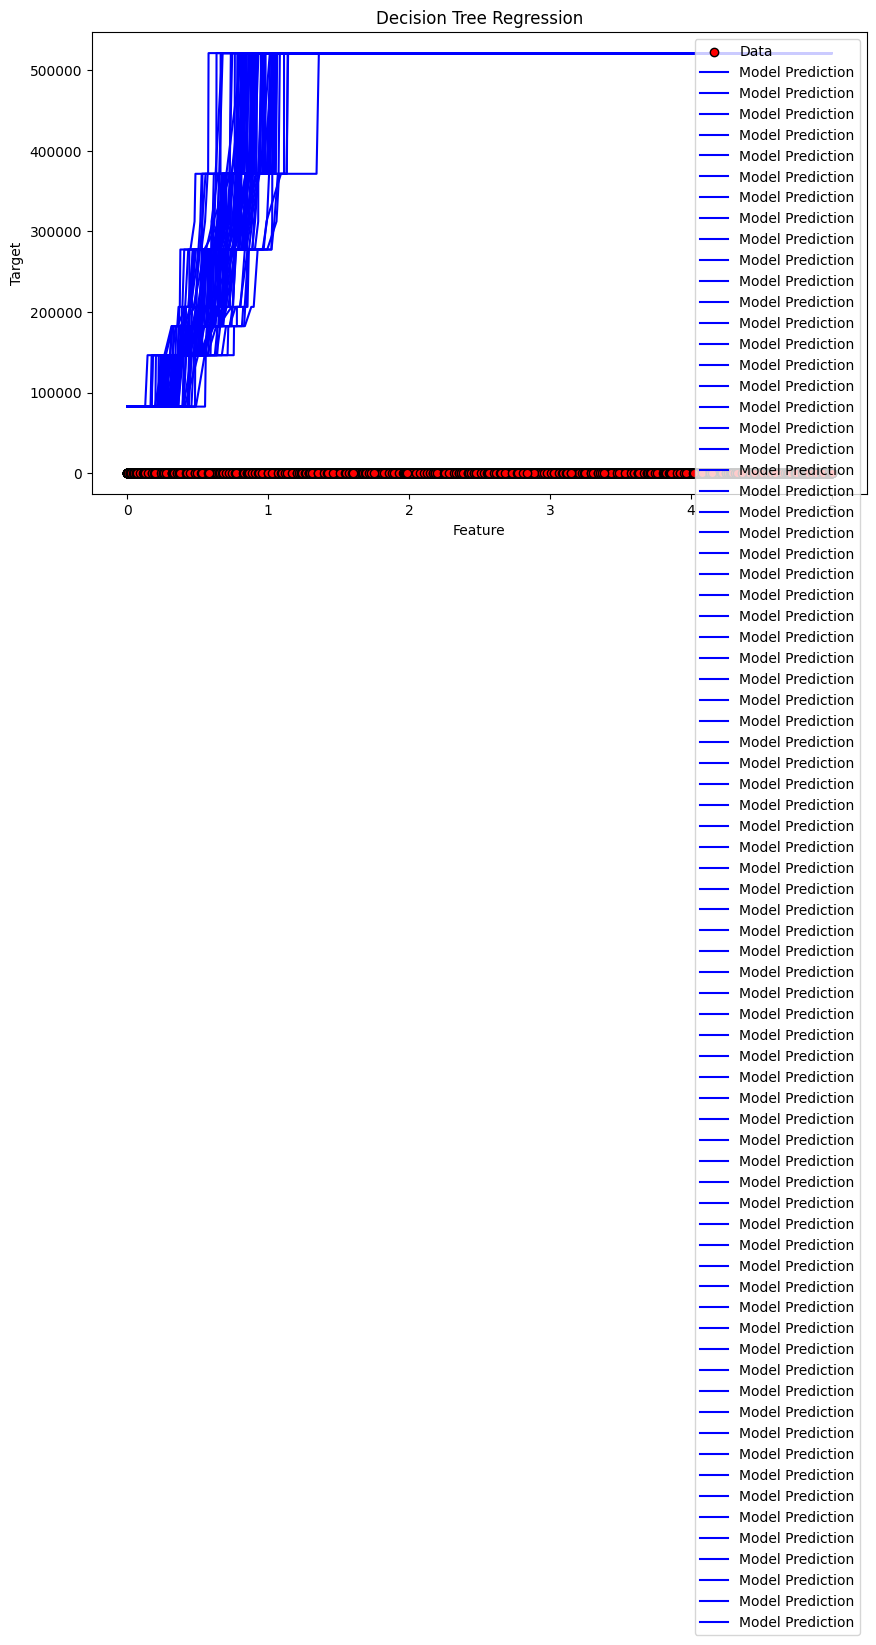

In [106]:
'''X_grid = np.arange(np.min(X), np.max(X), 0.01).reshape(-1,1)
print (X_grid)'''
y_grid_pred = regressor.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', edgecolor='k', label='Data')
plt.plot(X, y_grid_pred, color='blue', label='Model Prediction')
plt.title("Decision Tree Regression")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()

### Gradient Boost

In [29]:
# Train/test split and create preprocessing pipelines
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

TARGET = 'SalePrice'
X = df.drop(columns=[TARGET])
y = df[TARGET]

class_counts = y.value_counts()

# 2. Identify classes with more than 1 member
valid_classes = class_counts[class_counts > 1].index

# 3. Filter your data
mask = y.isin(valid_classes)
X = X[mask]
y = y[mask]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,stratify = y
)


print("Train:", X_train.shape, "Test:", X_test.shape)

# recompute types on train
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# preprocessing for sklearn GB (one-hot + scaling numeric)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor_sklearn = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# preprocessing for other models (ordinal encode categoricals, scale not required)
ordinal_transformer = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
])

# For CatBoost we'll pass raw data and list of categorical column names (it handles encoding)
print("Numeric cols:", len(num_cols), "Categorical cols:", len(cat_cols))

print("Numerical columns: ", num_cols)
print("Categorical columns: ", cat_cols)

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.pipeline import make_pipeline


gb_pipe = make_pipeline(preprocessor_sklearn, GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42
))
gb_pipe.fit(X_train, y_train)
proba_gb = gb_pipe.predict_proba(X_test)
print(f"Sklearn GB Test AUC: {roc_auc_score(y_test, proba_gb,multi_class='ovr'):.4f}")


Train: (737, 74) Test: (316, 74)
Numeric cols: 35 Categorical cols: 39
Numerical columns:  ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
Categorical columns:  ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'Kitchen

ValueError: Number of classes in y_true not equal to the number of columns in 'y_score'

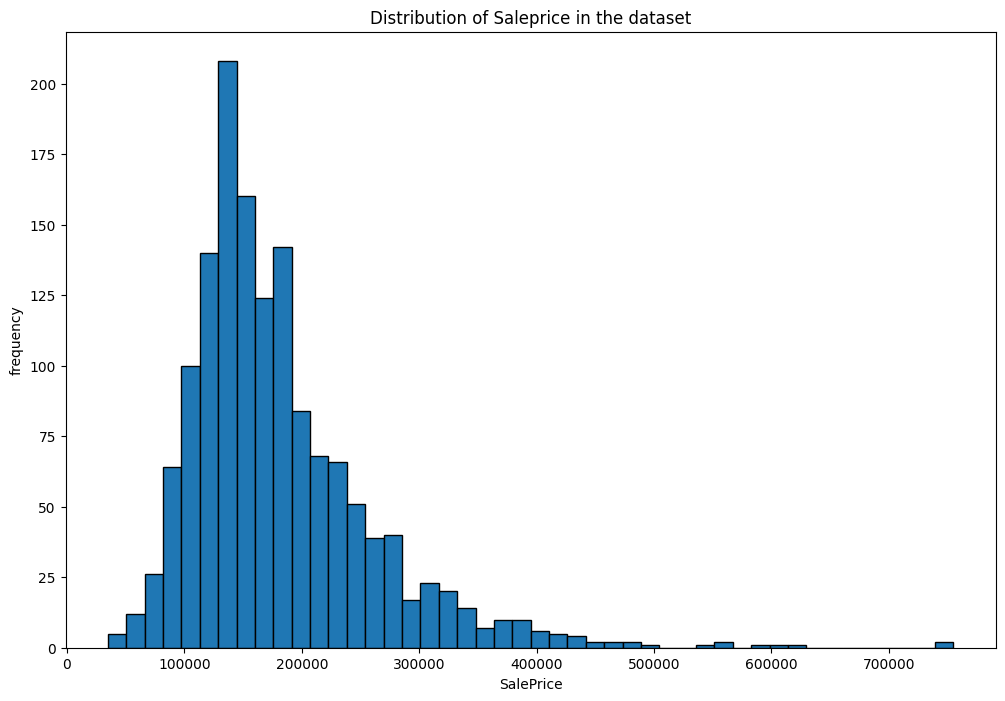

In [27]:
plt.figure(figsize=(12,8))
plt.hist(df['SalePrice'], bins=46, edgecolor='k')
plt.title("Distribution of Saleprice in the dataset")
plt.xlabel("SalePrice")
plt.ylabel("frequency")
plt.show()

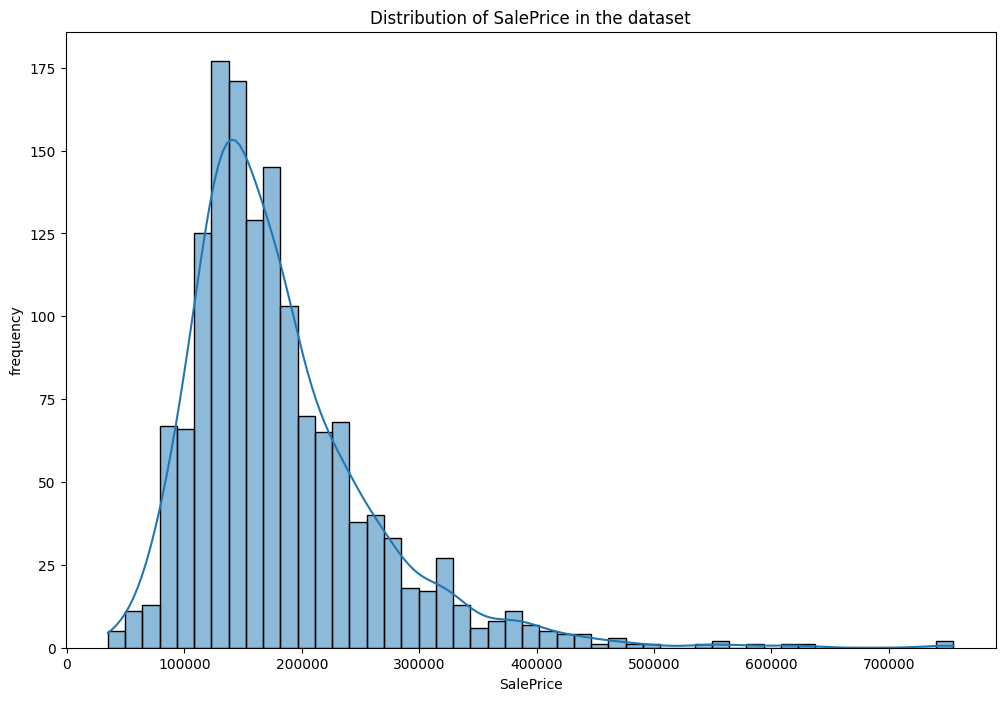

In [28]:
plt.figure(figsize=(12,8))
sns.histplot(df['SalePrice'], kde=True)
plt.title("Distribution of SalePrice in the dataset")
plt.xlabel("SalePrice")
plt.ylabel("frequency")
plt.show()

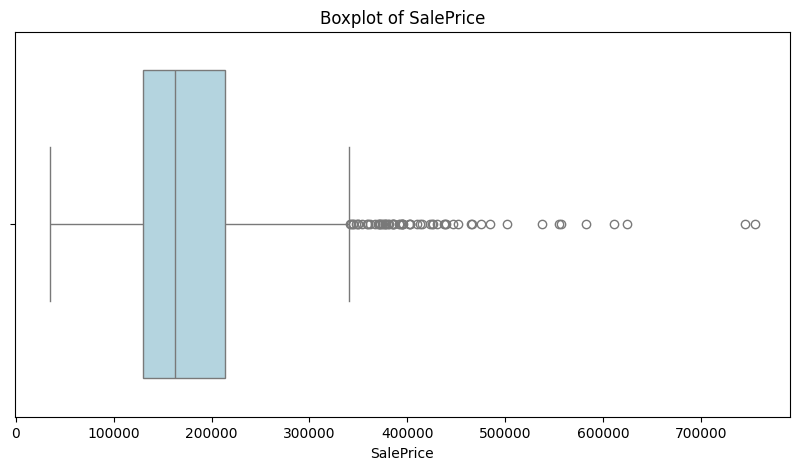

In [29]:
plt.figure(figsize=(10,5))
sns.boxplot(x = df['SalePrice'], color='lightblue')
plt.title("Boxplot of SalePrice")
plt.show()

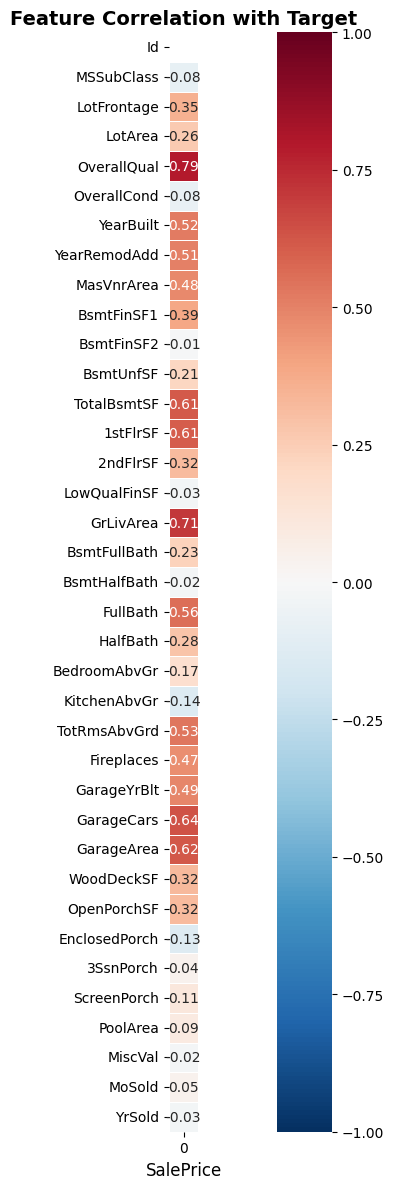

In [30]:
corr_with_target = numerical_df.drop(columns='SalePrice').corrwith(df['SalePrice'])
fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(pd.DataFrame(corr_with_target), dtype=bool))
sns.heatmap(pd.DataFrame(corr_with_target), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation with Target',
             fontsize=14, fontweight='bold')
ax.set_xlabel("SalePrice", fontsize=12)
plt.tight_layout()
plt.show()


Index(['Id', 'MSSubClass', 'LotArea', 'OverallCond', 'BsmtFinSF2', 'BsmtUnfSF',
       'LowQualFinSF', 'BsmtFullBath', 'BsmtHalfBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold'],
      dtype='object')


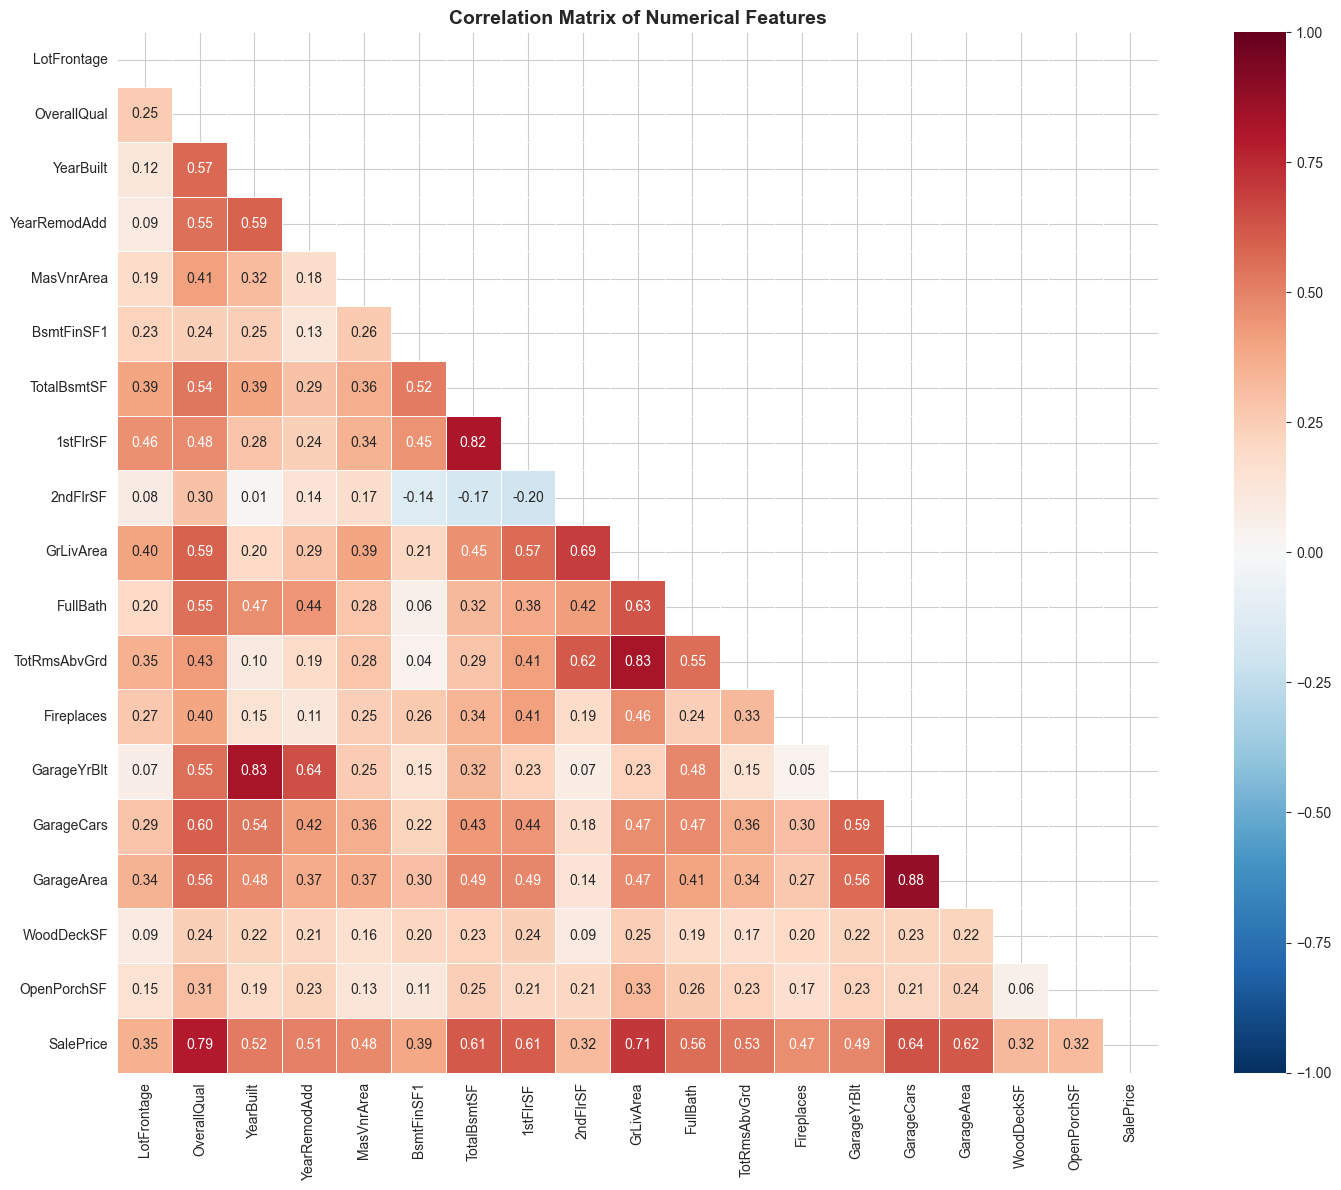

In [131]:
'''corr_matrix = df[numerical_cols + ['SalePrice']].corr()'''
corr_matrix = df.corr(numeric_only=True)
threshold = 0.3
low_impact_features = corr_matrix.columns[abs(corr_matrix['SalePrice']) < threshold]
print (low_impact_features)
'''corr_matrix.drop(columns=low_impact_features)'''
df=df.drop(columns=low_impact_features)
corr_matrix = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix of Numerical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()




In [132]:
df_new = df.copy()
df_new.drop(['Alley','PoolQC','Fence','MiscFeature'], axis=1,inplace=True)
print (df_new)
df_new.head()
print ("Removed all Numeric field whose thershold level between the field & target is less than 0.3")
print ("Removed Alley,PoolQC,Fence,MiscFeature are removed as null percentage is more than 70")

     MSZoning  LotFrontage Street LotShape LandContour Utilities LotConfig  \
0          RL         65.0   Pave      Reg         Lvl    AllPub    Inside   
1          RL         80.0   Pave      Reg         Lvl    AllPub       FR2   
2          RL         68.0   Pave      IR1         Lvl    AllPub    Inside   
3          RL         60.0   Pave      IR1         Lvl    AllPub    Corner   
4          RL         84.0   Pave      IR1         Lvl    AllPub       FR2   
...       ...          ...    ...      ...         ...       ...       ...   
1455       RL         62.0   Pave      Reg         Lvl    AllPub    Inside   
1456       RL         85.0   Pave      Reg         Lvl    AllPub    Inside   
1457       RL         66.0   Pave      Reg         Lvl    AllPub    Inside   
1458       RL         68.0   Pave      Reg         Lvl    AllPub    Inside   
1459       RL         75.0   Pave      Reg         Lvl    AllPub    Inside   

     LandSlope Neighborhood Condition1  ... GarageCars GarageAr

In [108]:
df_new['LotFrontage'] = df_new['LotFrontage'].fillna(df['LotFrontage'].mean())
df_new['FireplaceQu'] = df_new['FireplaceQu'].fillna(df_new['FireplaceQu'].mode()[0])
df_new['GarageType'] = df_new['GarageType'].fillna(df_new['GarageType'].mode()[0])
df_new['GarageYrBlt'] = df_new['GarageYrBlt'].fillna(df_new['GarageYrBlt'].mode()[0])
df_new['GarageFinish'] = df_new['GarageFinish'].fillna(df_new['GarageFinish'].mode()[0])
df_new['GarageQual'] = df_new['GarageQual'].fillna(df_new['GarageQual'].mode()[0])
df_new['GarageCond'] = df_new['GarageCond'].fillna(df_new['GarageCond'].mode()[0])
df_new['MasVnrType'] = df_new['MasVnrType'].fillna(df_new['MasVnrType'].mode()[0])
df_new['MasVnrArea'] = df_new['MasVnrArea'].fillna(df_new['MasVnrArea'].mode()[0])
df_new['BsmtQual'] = df_new['BsmtQual'].fillna('No')
df_new['BsmtCond'] = df_new['BsmtCond'].fillna(df_new['BsmtCond'].mode()[0])
df_new['BsmtExposure'] = df_new['BsmtExposure'].fillna(df_new['BsmtExposure'].mode()[0])
df_new['BsmtFinType1'] = df_new['BsmtFinType1'].fillna(df_new['BsmtFinType1'].mode()[0])
df_new['BsmtFinType2'] = df_new['BsmtFinType2'].fillna(df_new['BsmtFinType2'].mode()[0])
df_new['Electrical'] = df_new['Electrical'].fillna(df_new['Electrical'].mode()[0])


MSZoning


C:\Users\smjayaku\AppData\Local\Temp\ipykernel_9052\3702956385.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,8))


<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

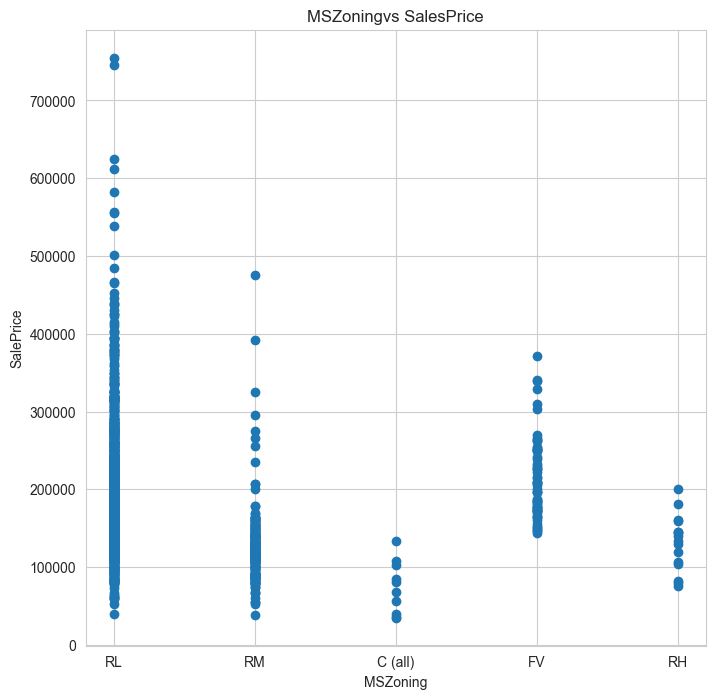

Street


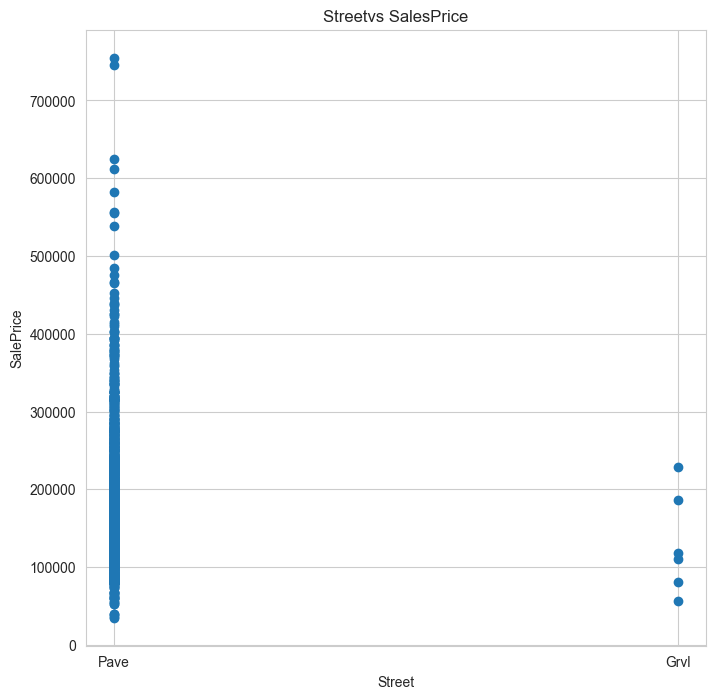

LotShape


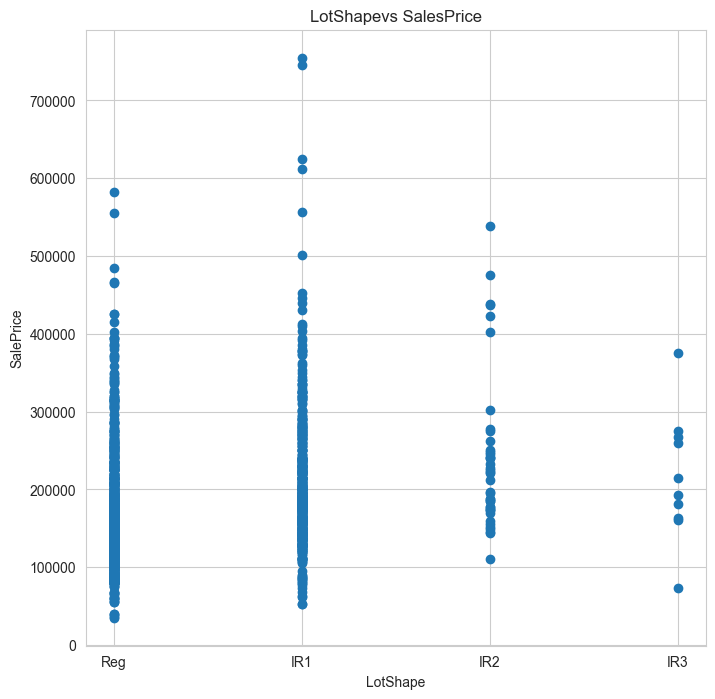

LandContour


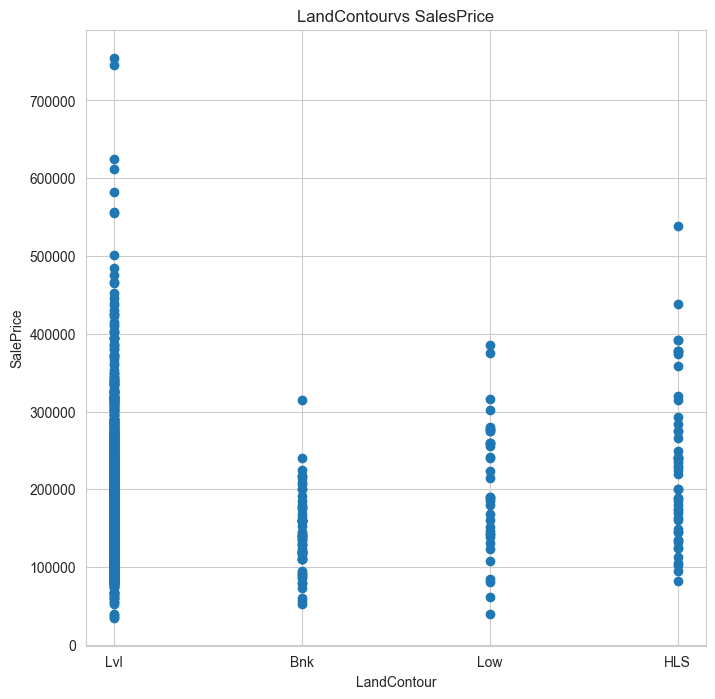

Utilities


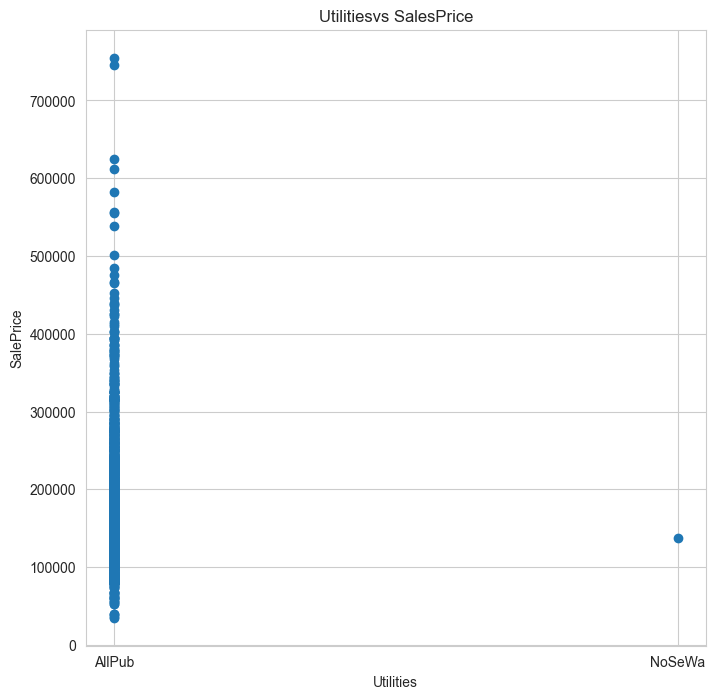

LotConfig


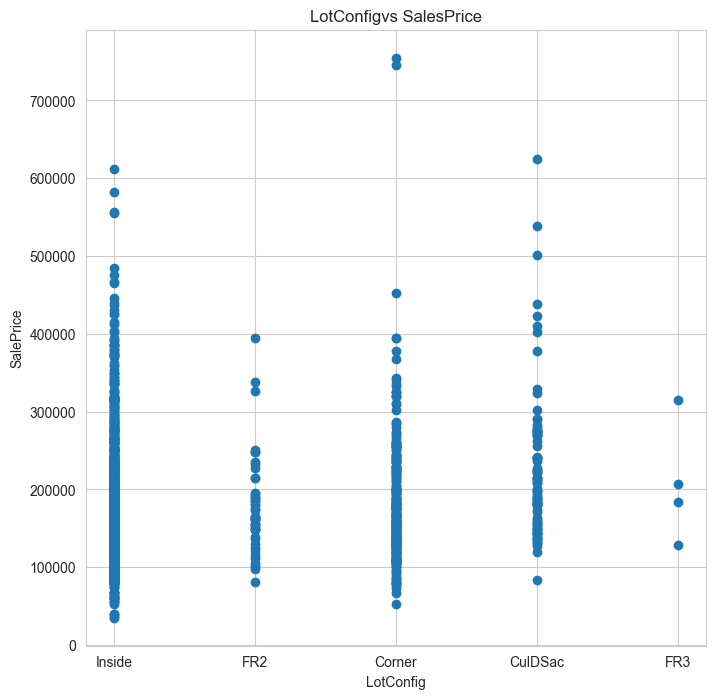

LandSlope


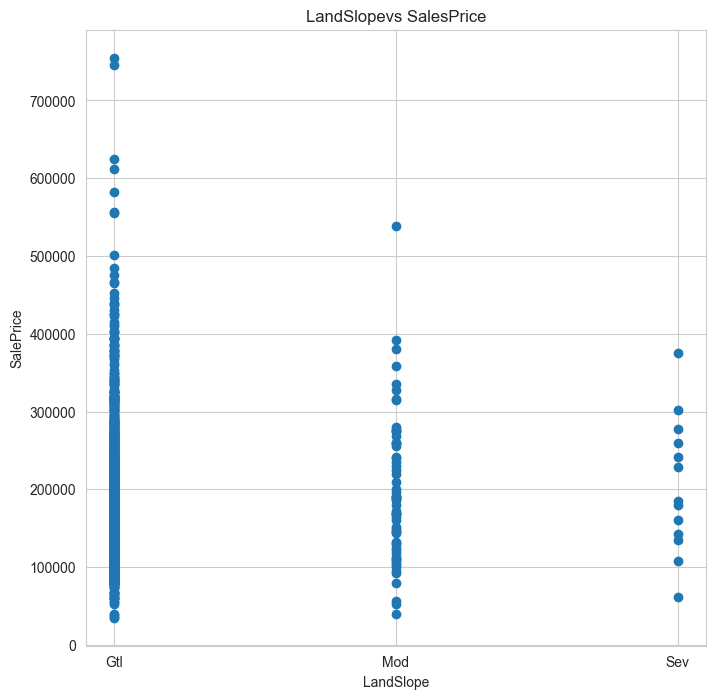

Neighborhood


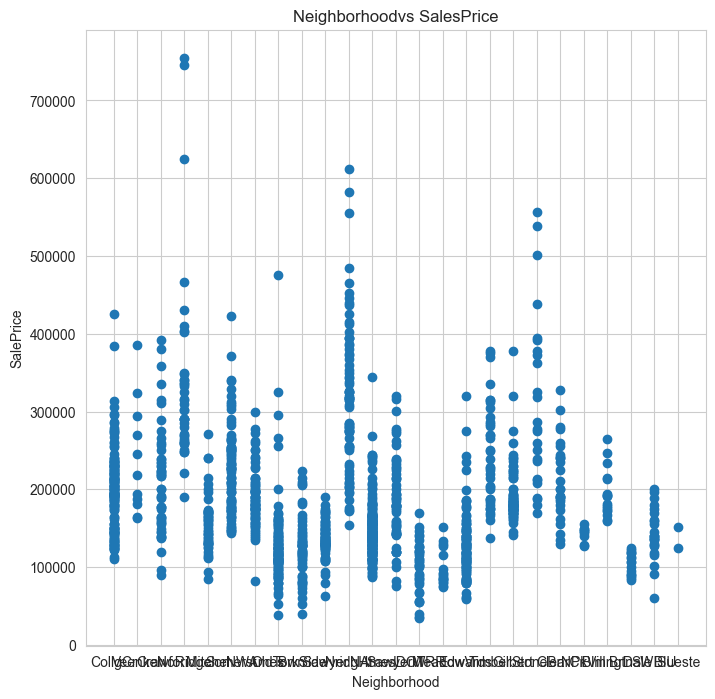

Condition1


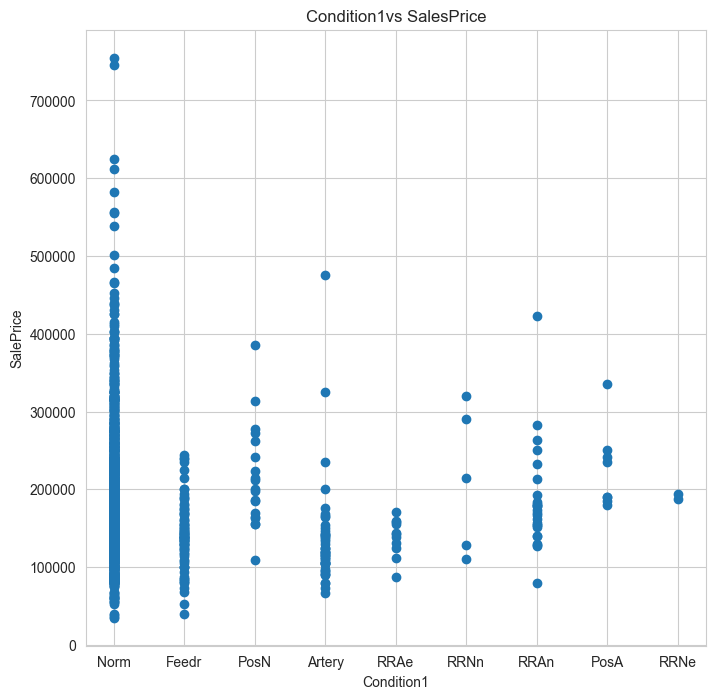

Condition2


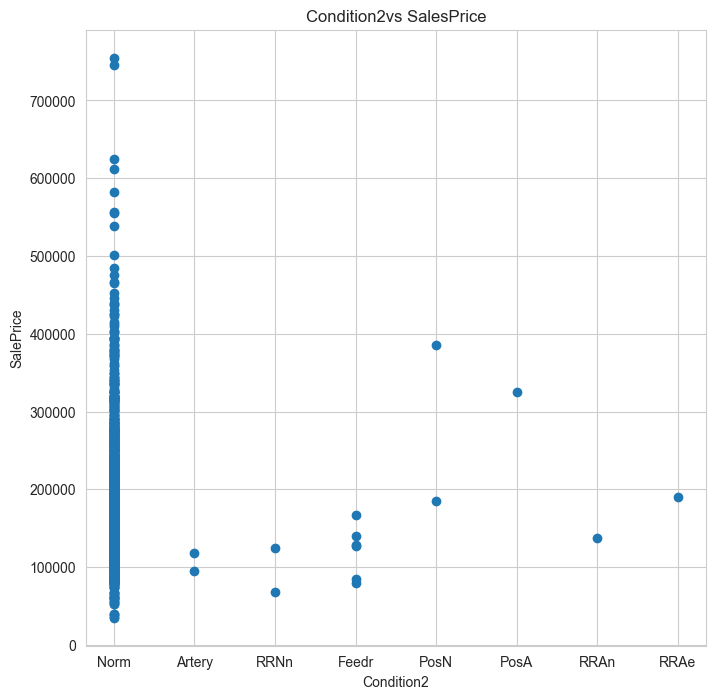

BldgType


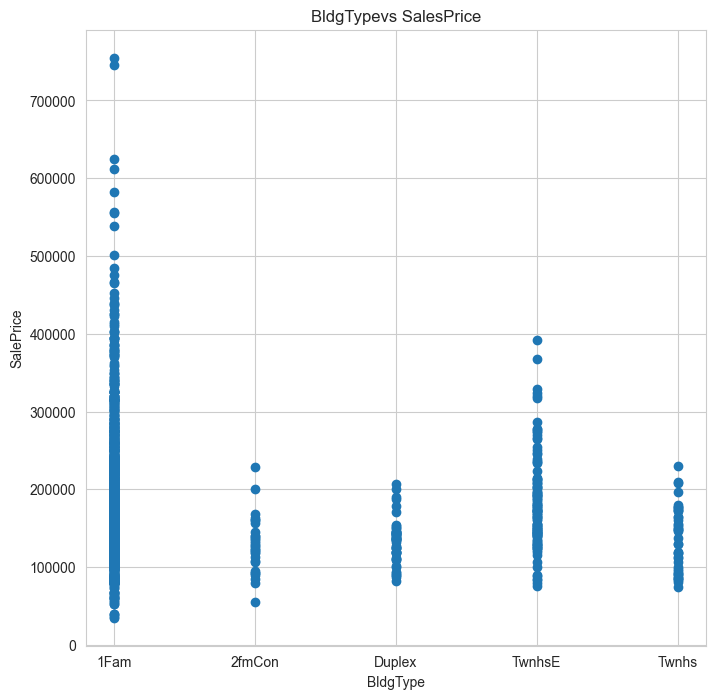

HouseStyle


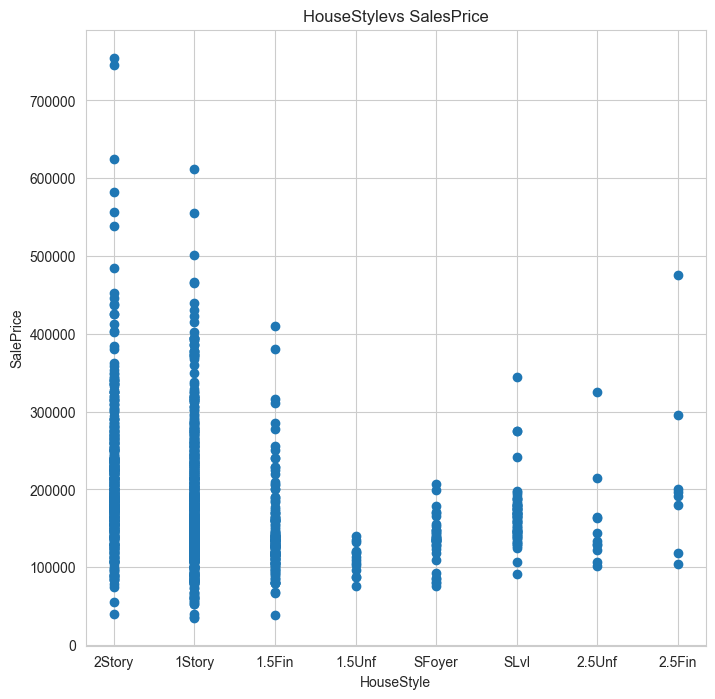

RoofStyle


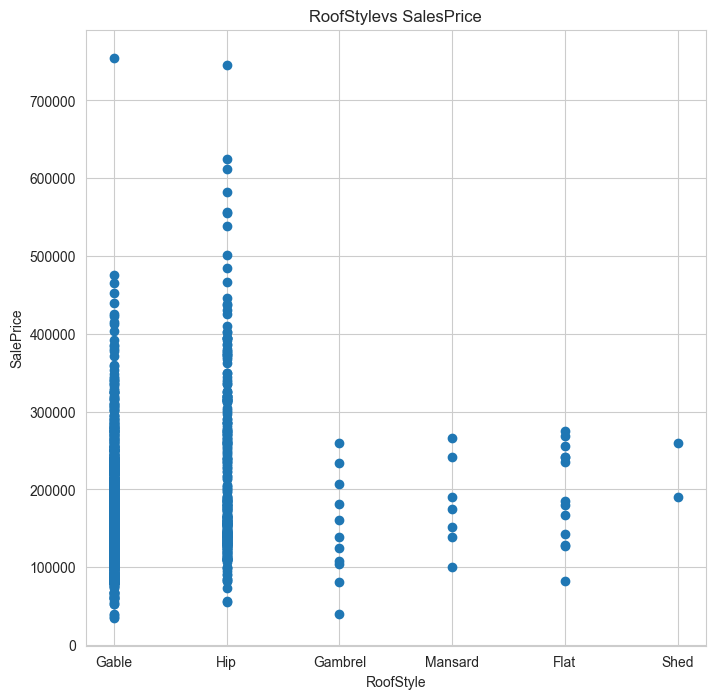

RoofMatl


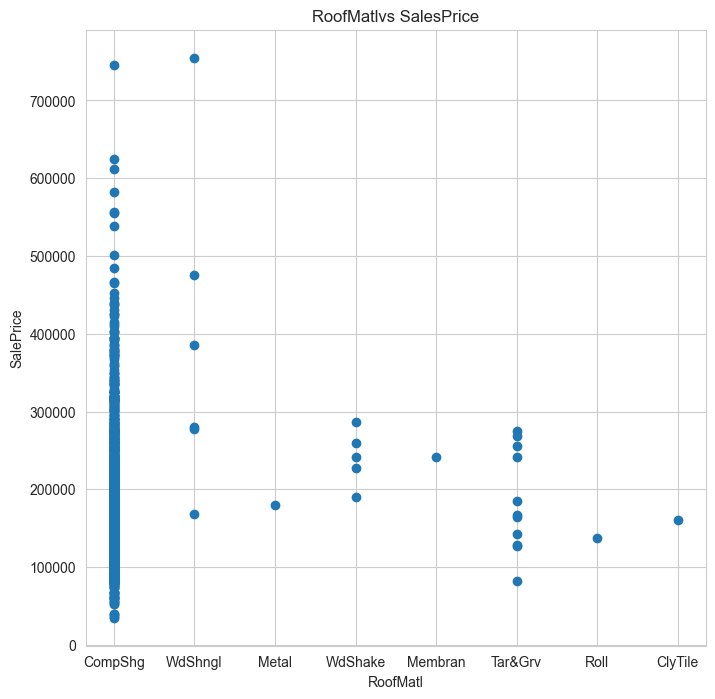

Exterior1st


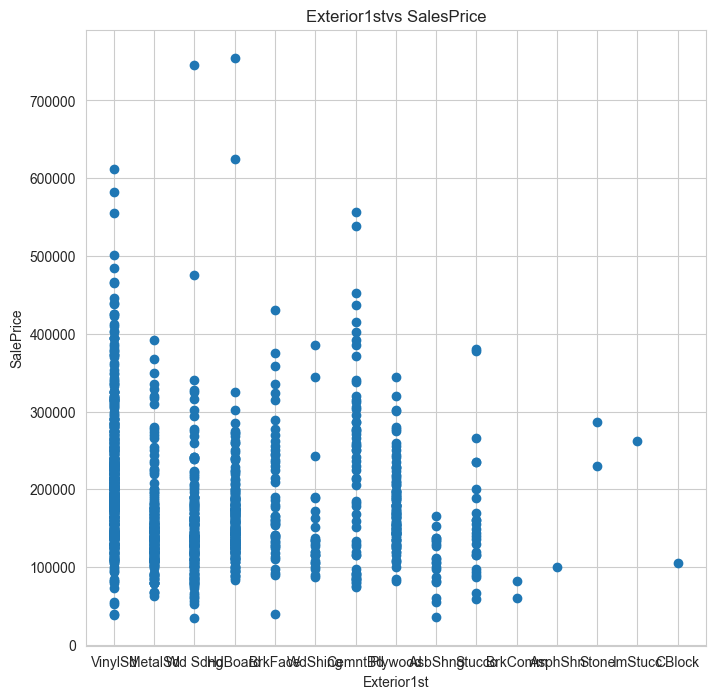

Exterior2nd


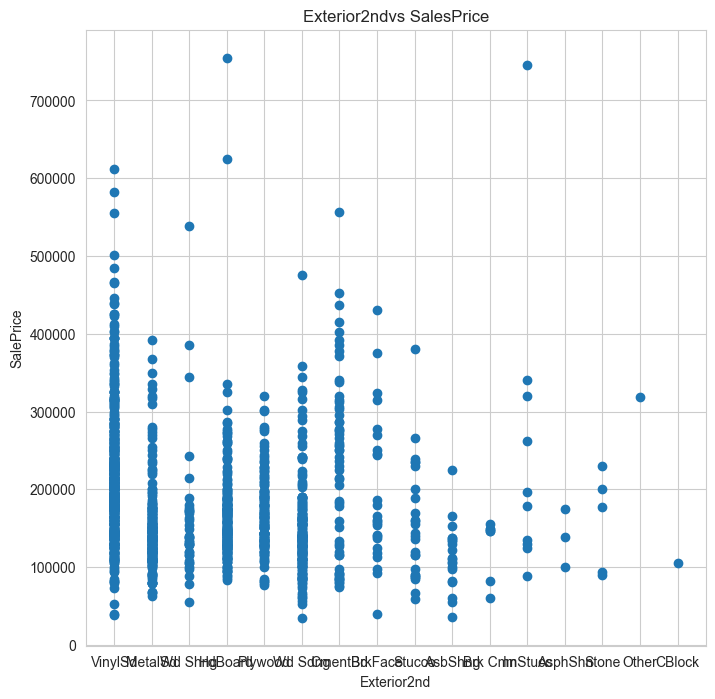

MasVnrType


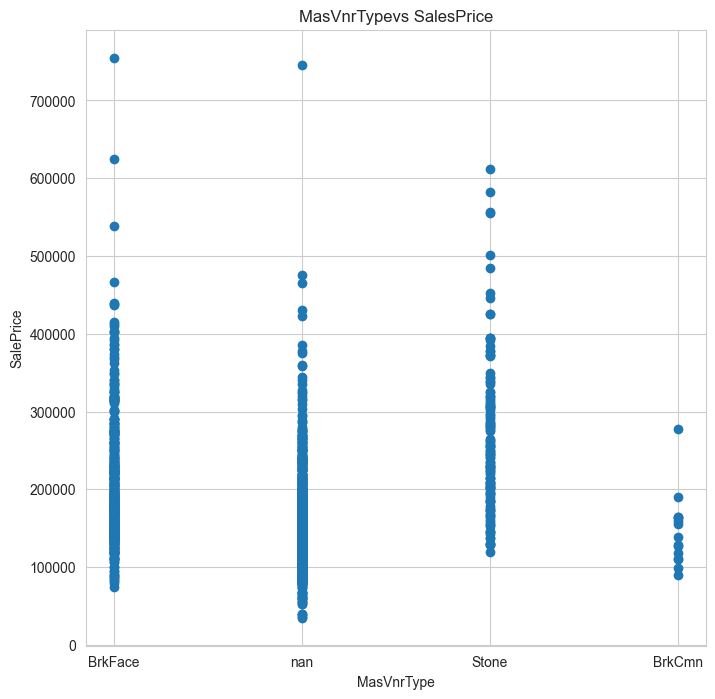

ExterQual


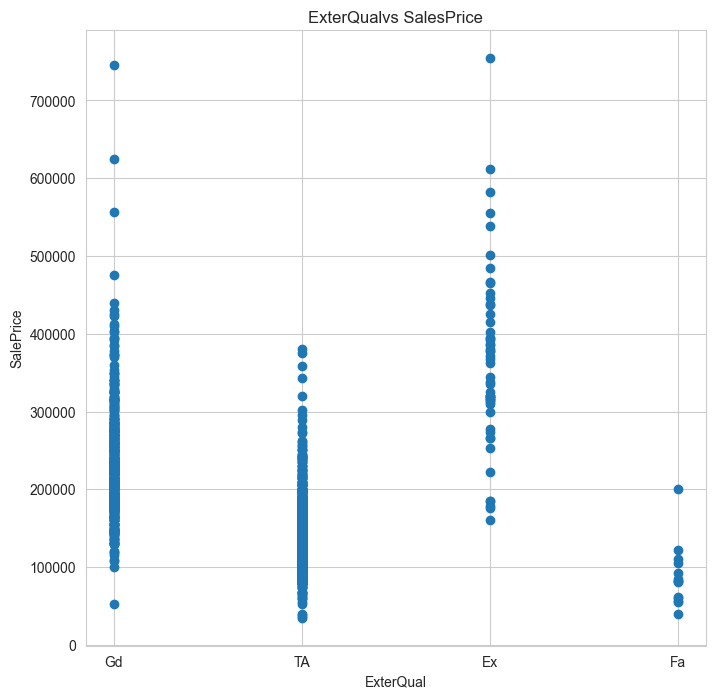

ExterCond


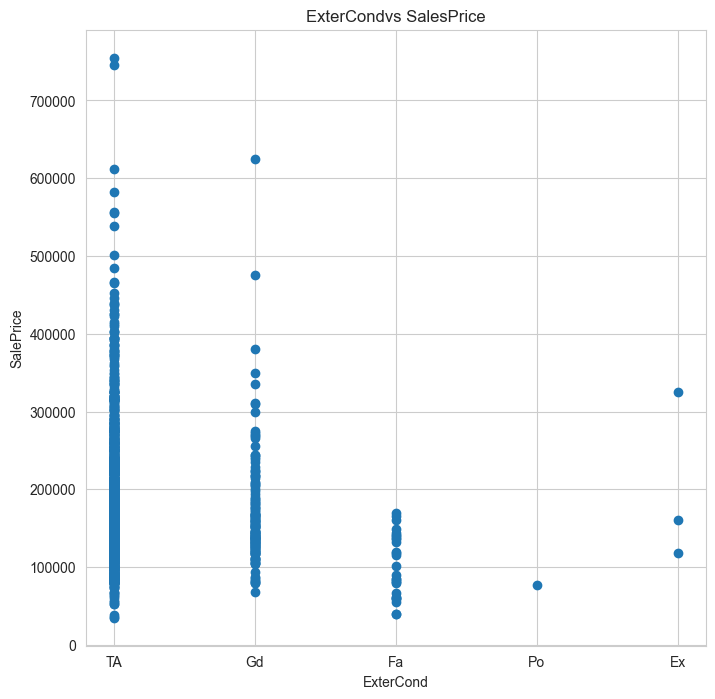

Foundation


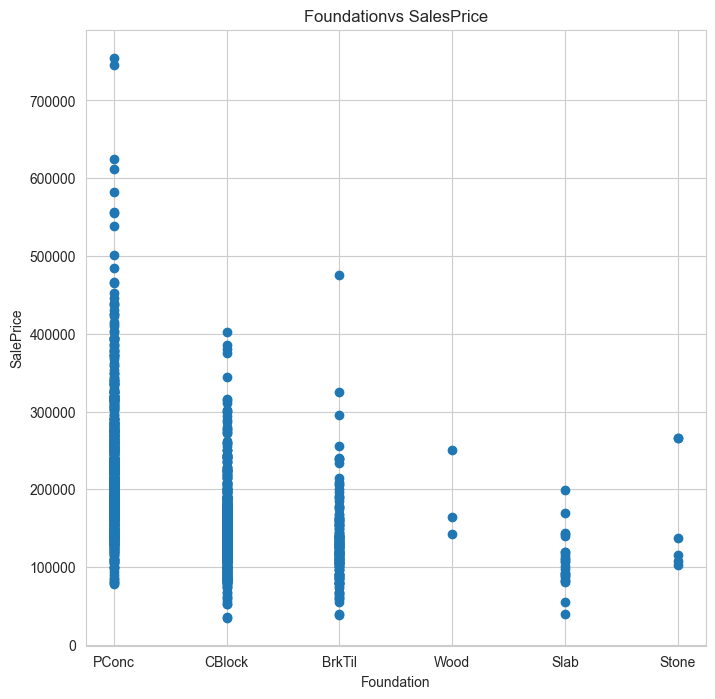

BsmtQual


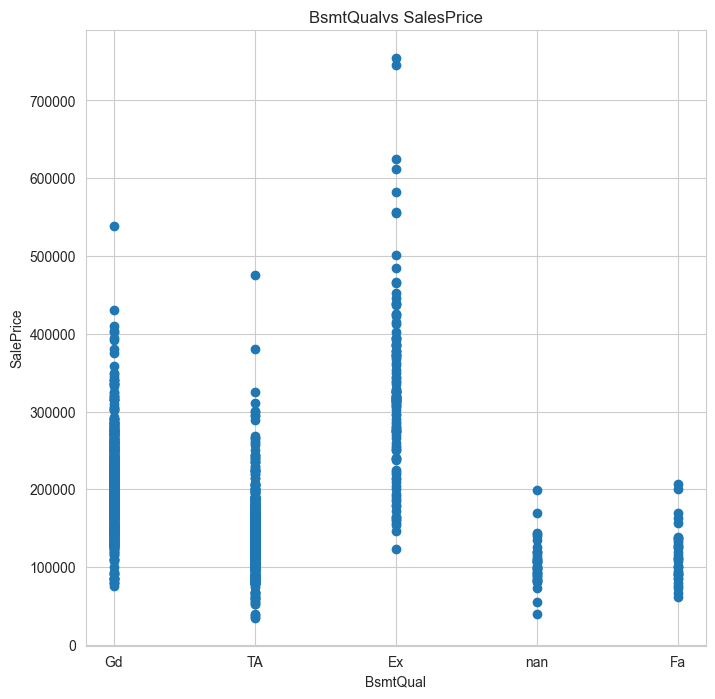

BsmtCond


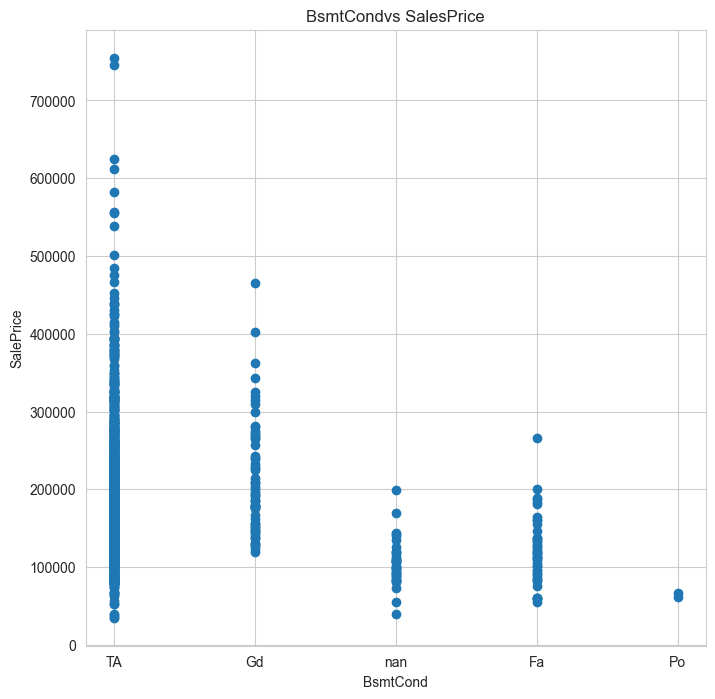

BsmtExposure


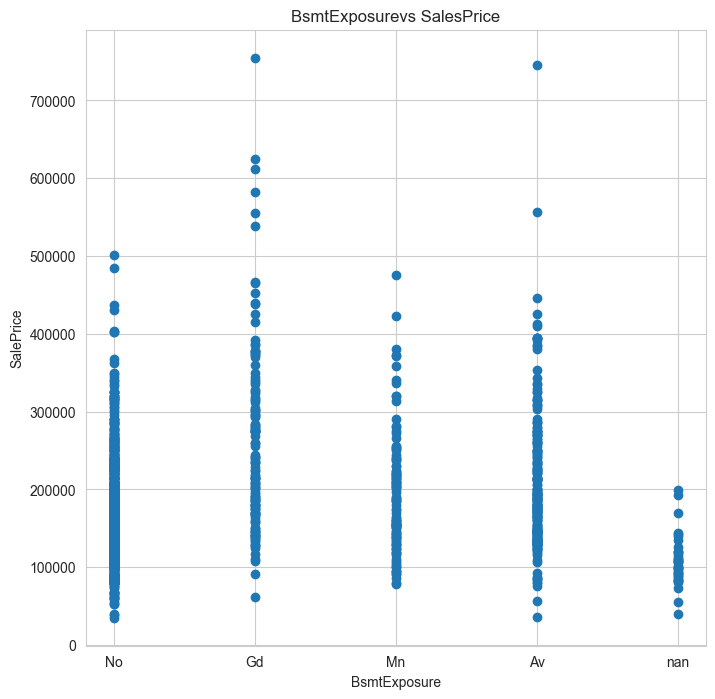

BsmtFinType1


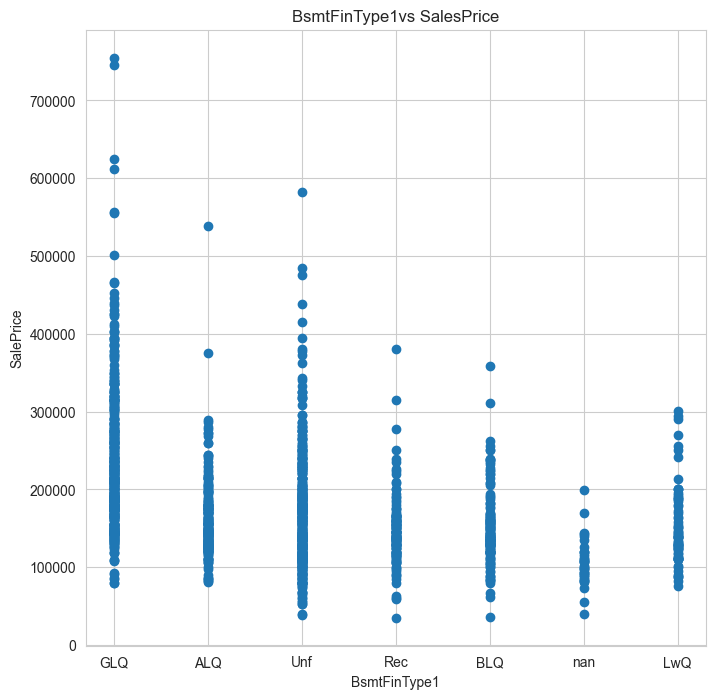

BsmtFinType2


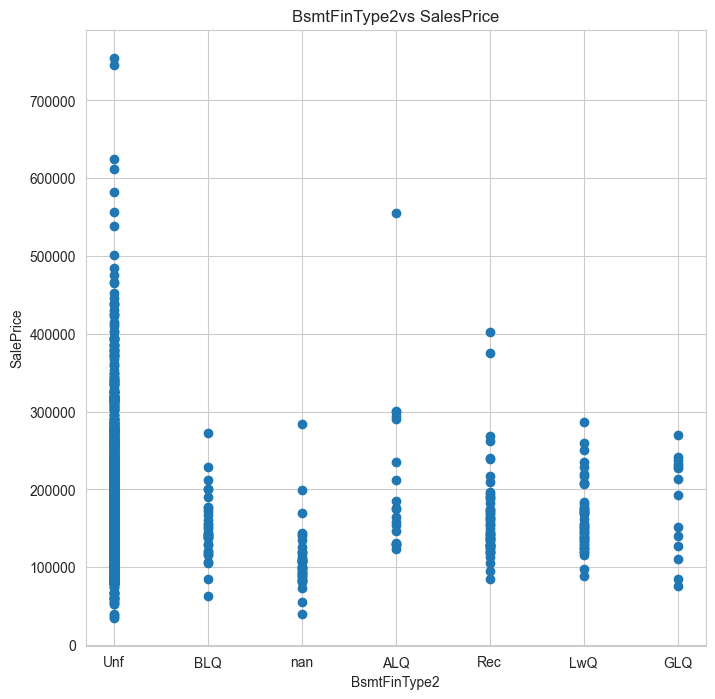

Heating


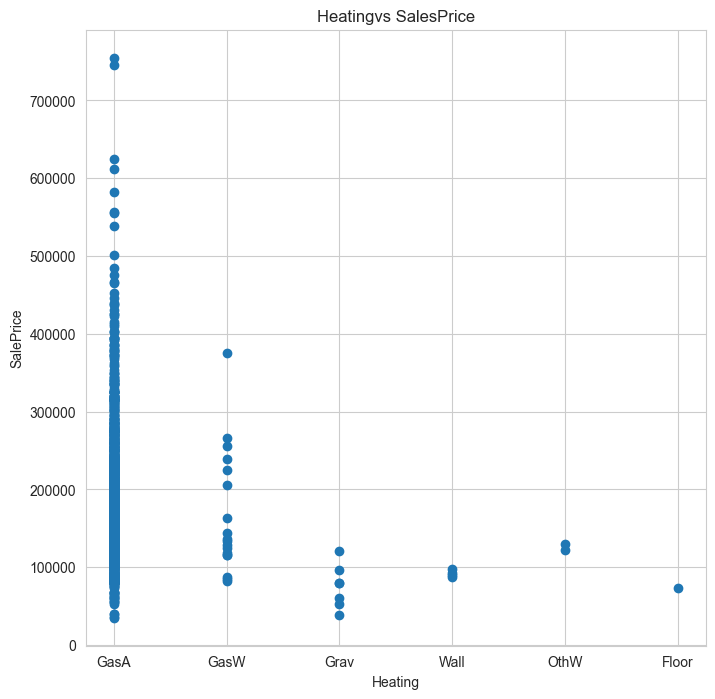

HeatingQC


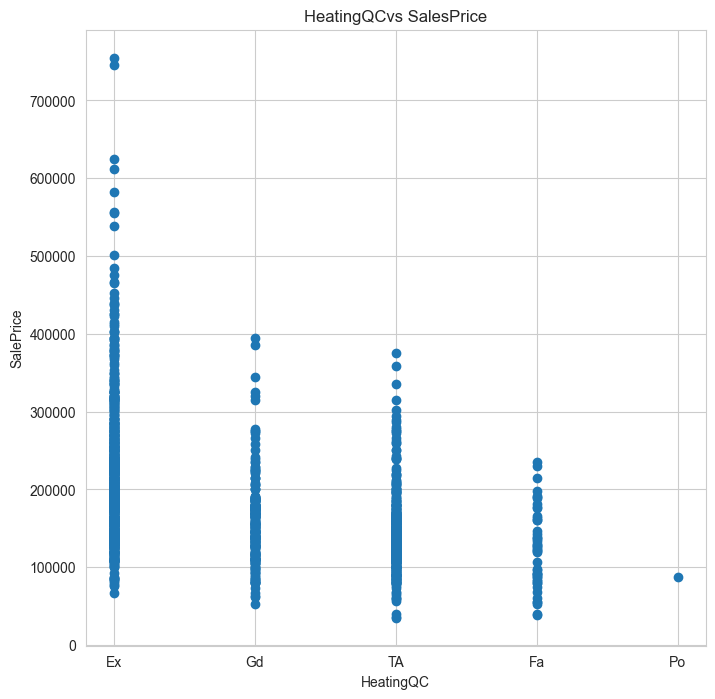

CentralAir


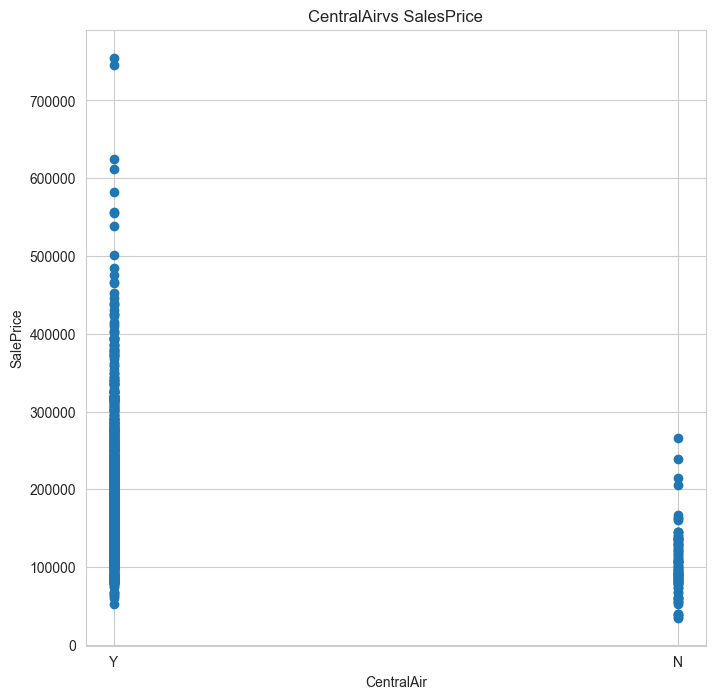

Electrical


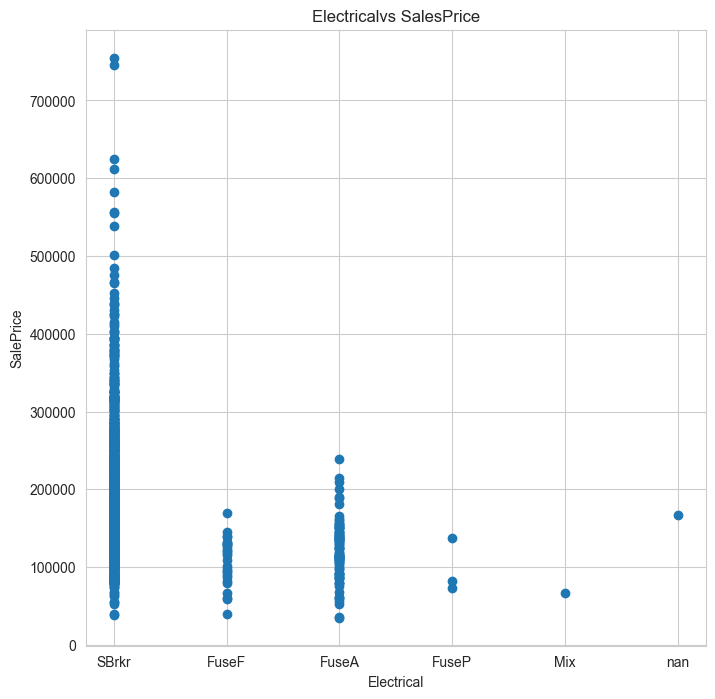

KitchenQual


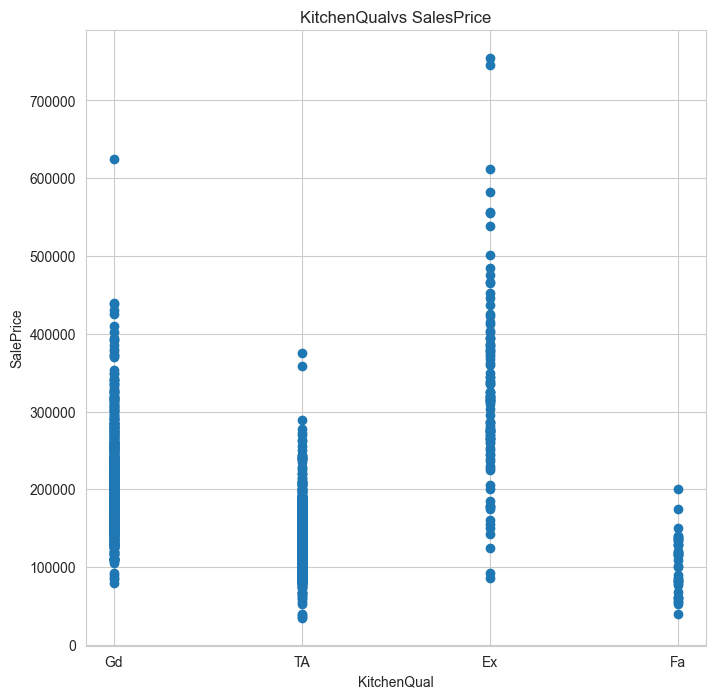

Functional


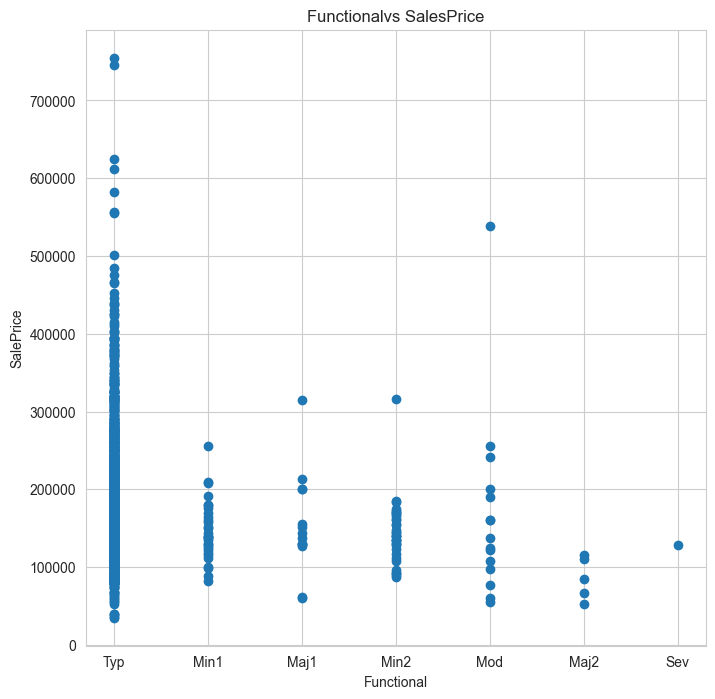

FireplaceQu


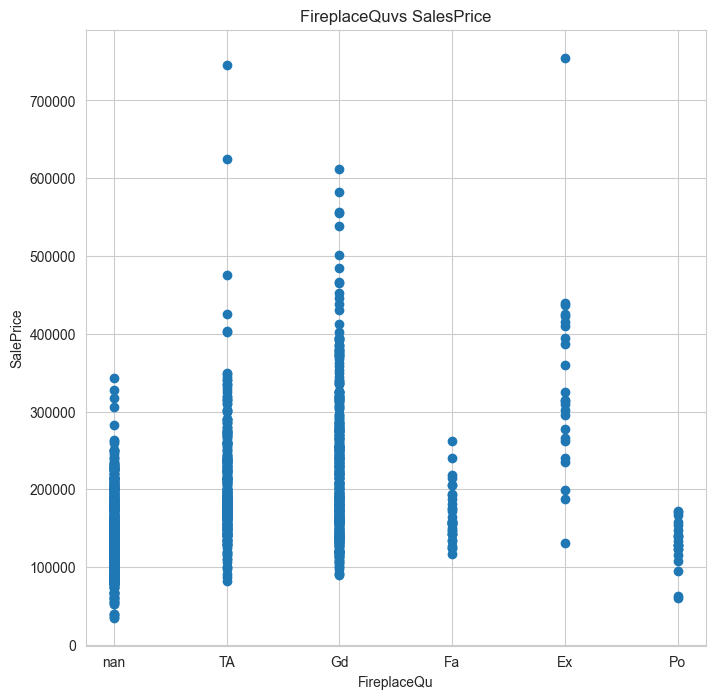

GarageType


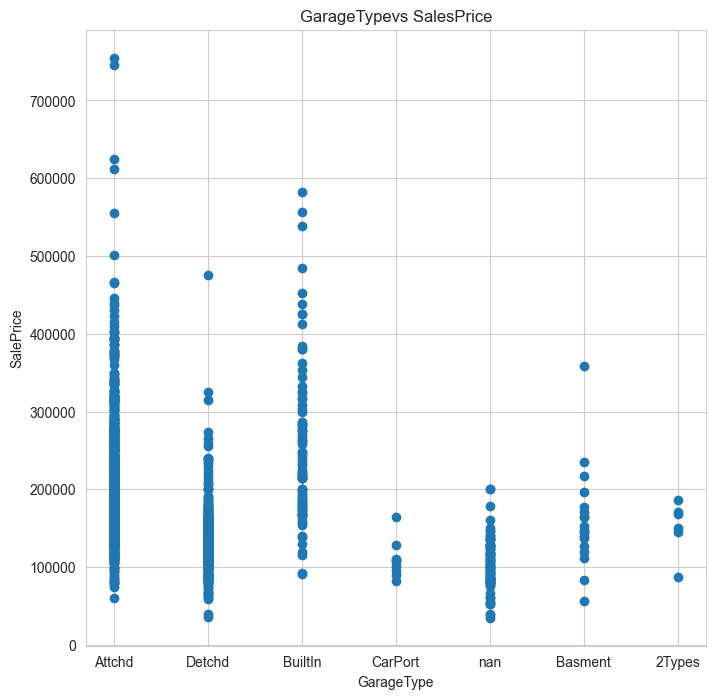

GarageFinish


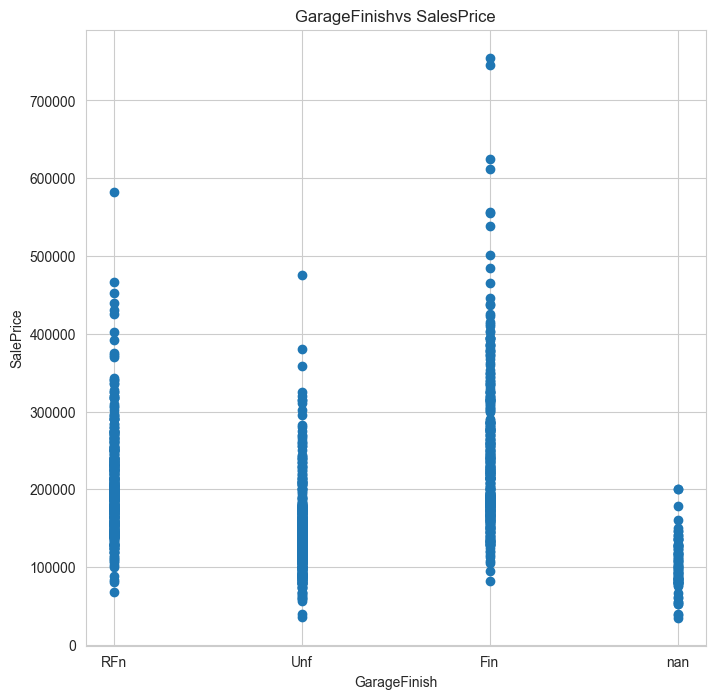

GarageQual


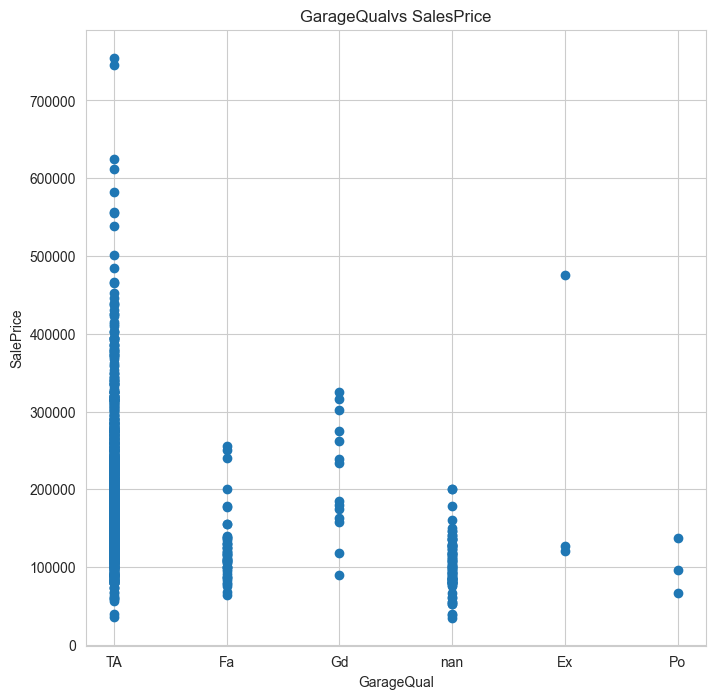

GarageCond


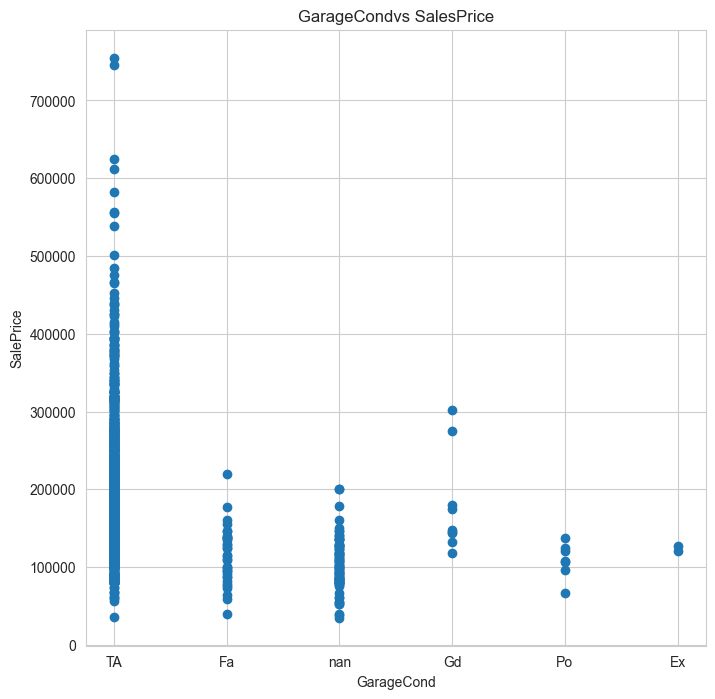

PavedDrive


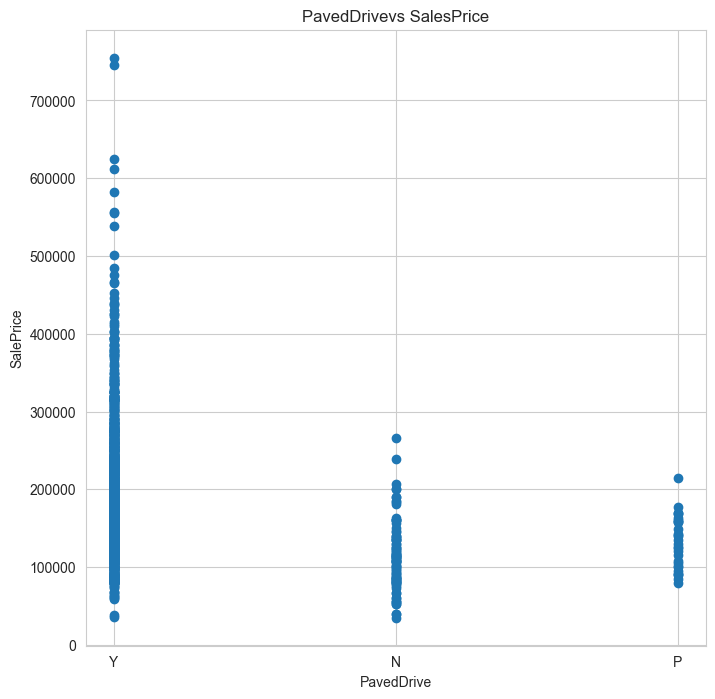

SaleType


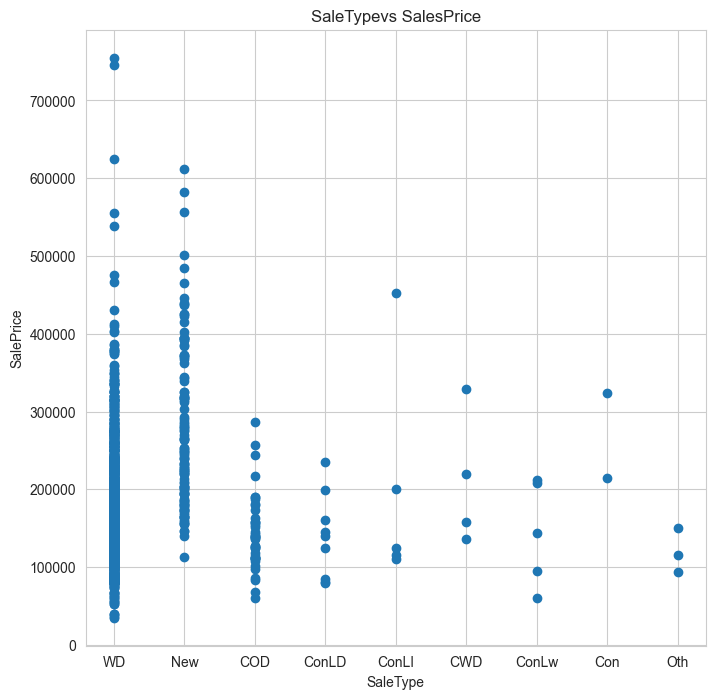

SaleCondition


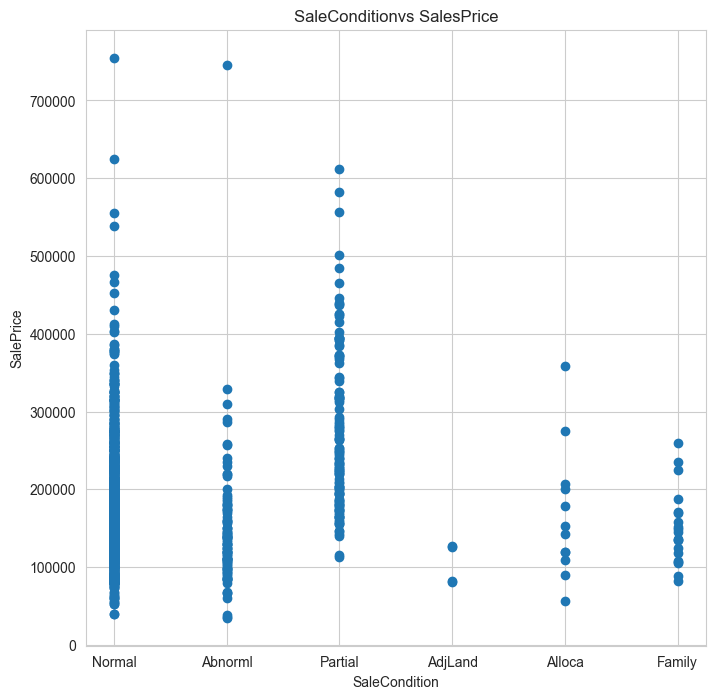

In [42]:
categorical_cols = df_new.select_dtypes(include=['object', 'category']).columns.tolist()
# Set up the plotting environment
sns.set_style("whitegrid")
target_column = 'SalePrice'
for col in categorical_cols:
    plt.figure(figsize=(8,8))
    # Set up the plotting environment
sns.set_style("whitegrid")
target_column = 'SalePrice'
for col in categorical_cols:
    print(col)
    plt.figure(figsize=(8,8))
    plt.scatter(df[col].astype(str), df['SalePrice'])
    plt.xlabel(col)
    plt.ylabel(target_column)
    plt.title(col + "vs SalesPrice")
    plt.show()
     


In [134]:
# 1. Encode categorical data
le = LabelEncoder()
df_encoded = category_df.apply(le.fit_transform)

# 2. Identify Impact (e.g., Chi-Squared)
X = df_encoded
y = df_new['SalePrice']

# Select top 1 feature, indicating lower impact ones to drop
selector = SelectKBest(chi2, k=6)
selector.fit(X, y)
print (selector.fit(X, y))
columns_to_keep = X.columns[selector.get_support()]
print (columns_to_keep)
columns_to_drop = [col for col in X.columns if col not in columns_to_keep]
print (columns_to_drop)
# 3. Drop low-impact features
'''df_new.drop(columns_to_drop, axis=1, inplace=True)
print(df_new)'''

SelectKBest(k=6, score_func=<function chi2 at 0x000001680E03B740>)
Index(['LandSlope', 'Neighborhood', 'BldgType', 'BsmtFinType1', 'HeatingQC',
       'GarageType'],
      dtype='object')
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'Condition1', 'Condition2', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


'df_new.drop(columns_to_drop, axis=1, inplace=True)\nprint(df_new)'